In [7]:
import os
import pandas as pd
import numpy as np
import torch

torch.set_default_dtype(torch.float32)


# Constants
path = "/Users/darenpalmer/Desktop/UCL/CS/fyp.nosync/data/carOBD/obdiidata"
sensor_cols = target_columns = [
    'ENGINE_RPM ()',                    # correlates with speed, load
    'VEHICLE_SPEED ()',                 # VSS glitch detection
    'THROTTLE ()',                      # TPS drift, throttle-load correlation
    'ENGINE_LOAD ()',                   # pair with throttle for mismatch
    'COOLANT_TEMPERATURE ()',           # intermittent sensor faults
    'INTAKE_MANIFOLD_PRESSURE ()',      # MAF/MAP drift detection
    'SHORT_TERM_FUEL_TRIM_BANK_1 ()',  # critical for air/fuel faults
    'LONG_TERM_FUEL_TRIM_BANK_1 ()',   # detects persistent issues
]

id_col = "drive_id"
time_col = 'ENGINE_RUN_TINE ()'
window_size = 300     # 300
forecast_horizon = 1

# %%
df_list = []
for file in os.listdir(path):
    if file.endswith('.csv'):
        df = pd.read_csv(f'{path}/{file}', index_col=False)
        df['drive_id'] = file
        df_list.append(df)


print(f'{len(df_list)} files loaded out of {len([f for f in os.listdir(path) if f.endswith(".csv")])}')


# %%
def remove_zero_variance_columns(df: pd.DataFrame, exclude_cols: list[str] = None) -> pd.DataFrame:
    """
    Compute std of each std-computable column (numeric only)
    """
    if exclude_cols is None:
        exclude_cols = []
    
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    cols_to_check = [col for col in numeric_cols if col not in exclude_cols]
  
    std_df = df[cols_to_check].std()
    zero_variance_cols = std_df[std_df == 0].index.tolist()
  
    print(f'{len(zero_variance_cols)} columns with zero variance: {zero_variance_cols}')
  
    if len(zero_variance_cols) > 0:
        df = df.drop(columns=zero_variance_cols)
  
    return df


# %%
def mean_fill_missing_timestamps_and_remove_duplicates(df: pd.DataFrame, time_col: str, id_cols: list[str] = None) -> pd.DataFrame:
    """
    Remove duplicate timestamps by averaging all numeric columns for each unique timestamp.
    This preserves the overall statistics while removing duplicate entries.
    
    Note: The time column itself is not averaged (it becomes the group key).
    Only numeric columns are averaged when multiple rows share the same timestamp.
    """
    if id_cols is None:
        id_cols = []
    
    existing_id_cols = [col for col in id_cols if col in df.columns]
    
    group_cols = [time_col] + existing_id_cols
    
    agg_dict = {}
    for col in df.columns:
        if col not in group_cols:
            if pd.api.types.is_numeric_dtype(df[col]):
                agg_dict[col] = 'mean'
            else:
                agg_dict[col] = 'first'
  
    df_clean = df.groupby(group_cols, as_index=False).agg(agg_dict)
  
    return df_clean


# %%
def downsample(df, time_col, source_file_col, downsample_factor=2):
    result_dfs = []
    
    for source_file in df[source_file_col].unique():
        file_df = df[df[source_file_col] == source_file].copy()
        
        if len(file_df) < downsample_factor * 2:
            continue
        
        file_df = file_df.sort_values(time_col).reset_index(drop=True)
        
        # Simple decimation without pre-smoothing
        downsampled = file_df.iloc[::downsample_factor].copy()
        downsampled[time_col] = np.arange(len(downsampled)) * downsample_factor
        
        result_dfs.append(downsampled.reset_index(drop=True))
    
    return pd.concat(result_dfs, ignore_index=True)


# %%
def filter_long_drives(df, id_col='drive_id', min_length=608):
    """Keep only drives long enough for your context window"""
    drive_lengths = df.groupby(id_col).size()
    valid_drives = drive_lengths[drive_lengths >= min_length].index
    
    print(f"Keeping {len(valid_drives)}/{df[id_col].nunique()} drives")
    print(f"Dropped {len(df) - df[df[id_col].isin(valid_drives)].shape[0]} timesteps")
    
    return df[df[id_col].isin(valid_drives)].reset_index(drop=True)


# %%
# Combine all dataframes
data = pd.concat(df_list, ignore_index=True)


# Clean up
print(f"Total samples: {len(data):,}")
print(f"Unique drives: {data['drive_id'].nunique()}")


# remove some useless columns
data = data.drop(columns=['WARM_UPS_SINCE_CODES_CLEARED ()', 'TIME_SINCE_TROUBLE_CODES_CLEARED ()'])


data = mean_fill_missing_timestamps_and_remove_duplicates(data, time_col=time_col, id_cols=["drive_id"])
data = remove_zero_variance_columns(data, exclude_cols=["drive_id"])
data = downsample(
    data,
    time_col=time_col,
    source_file_col='drive_id',
    downsample_factor=1
)


data = filter_long_drives(data, min_length=window_size + forecast_horizon)


# %%
def add_cross_channel_features(data):
    """
    Engineer features that capture cross-channel relationships.
    Add these as conditional columns.
    """
    # RPM-to-Speed ratio (gear indicator)
    if 'ENGINE_RPM ()' in data.columns and 'VEHICLE_SPEED ()' in data.columns:
        data['RPM_SPEED_RATIO'] = data['ENGINE_RPM ()'] / (data['VEHICLE_SPEED ()'] + 1)
    
    # Throttle-to-Load ratio (efficiency indicator)
    if 'THROTTLE ()' in data.columns and 'ENGINE_LOAD ()' in data.columns:
        data['THROTTLE_LOAD_RATIO'] = data['THROTTLE ()'] / (data['ENGINE_LOAD ()'] + 1)
    
    # Speed-based categories
    if 'VEHICLE_SPEED ()' in data.columns:
        data['IS_IDLE'] = (data['VEHICLE_SPEED ()'] < 5).astype(float)
        data['IS_HIGHWAY'] = (data['VEHICLE_SPEED ()'] > 60).astype(float)
    
    # RPM acceleration
    if 'ENGINE_RPM ()' in data.columns:
        data['RPM_ACCEL'] = data.groupby('drive_id')['ENGINE_RPM ()'].diff().fillna(0)
    
    return data


# Apply cross-channel features before preprocessing
data = add_cross_channel_features(data)
print("Added cross-channel features")


# %%
import numpy as np
import pandas as pd


# Ensure data is sorted
data = data.sort_values(["drive_id", time_col]).reset_index(drop=True)


# Get unique drive IDs
unique_drives = data['drive_id'].unique()
n_drives = len(unique_drives)


# Split drives into train/val/test groups (70/15/15)
train_drives = unique_drives[:int(0.70 * n_drives)]
val_drives   = unique_drives[int(0.70 * n_drives):int(0.85 * n_drives)]
test_drives  = unique_drives[int(0.85 * n_drives):]


print(f"Train drives: {len(train_drives)}, Val drives: {len(val_drives)}, Test drives: {len(test_drives)}")


# Create split dataframes
train_data = data[data['drive_id'].isin(train_drives)].copy()
val_data   = data[data['drive_id'].isin(val_drives)].copy()
test_data  = data[data['drive_id'].isin(test_drives)].copy()


print(f"Train shape: {train_data.shape}, Val shape: {val_data.shape}, Test shape: {test_data.shape}")

129 files loaded out of 129
Total samples: 304,299
Unique drives: 129
3 columns with zero variance: ['FUEL_AIR_COMMANDED_EQUIV_RATIO ()', 'TIME_RUN_WITH_MIL_ON ()', 'DISTANCE_TRAVELED_WITH_MIL_ON ()']
Keeping 118/129 drives
Dropped 2572 timesteps
Added cross-channel features
Train drives: 82, Val drives: 18, Test drives: 18
Train shape: (49402, 28), Val shape: (17960, 28), Test shape: (12473, 28)


In [8]:
def inject_faults_with_sensor_labels(X_windows, y_windows, sensor_cols, 
                                     fault_percentage=0.30, random_state=42):
    """
    Inject faults and return SENSOR-LEVEL labels.
    
    Returns:
    - X_faulty: (N, W, D) window data with injected faults
    - y_windows: (N, D) unchanged target values
    - sensor_labels: (N, D) binary matrix - 1 if sensor i is faulty in window j
    - window_labels: (N,) binary - 1 if any fault exists in window
    """
    np.random.seed(random_state)
    
    N, W, D = X_windows.shape
    n_fault = max(1, int(N * fault_percentage))
    
    X_faulty = X_windows.clone()
    sensor_labels = torch.zeros(N, D, dtype=torch.float32)
    window_labels = torch.zeros(N, dtype=torch.long)
    
    fault_indices = np.random.choice(N, n_fault, replace=False)
    pid_idx = {name: i for i, name in enumerate(sensor_cols)}
    
    for idx in fault_indices:
        win = X_faulty[idx].numpy()
        
        fault_type = np.random.choice([
            'vss_dropout', 'maf_scale_low', 'coolant_dropout', 
            'tps_stuck', 'rpm_speed_decouple'
        ], p=[0.35, 0.25, 0.20, 0.10, 0.10])
        
        affected_sensors = []
        
        # ===== FAULT 1: VSS DROPOUT =====
        if fault_type == 'vss_dropout' and 'VEHICLE_SPEED ()' in pid_idx:
            speed_i = pid_idx['VEHICLE_SPEED ()']
            if win[:, speed_i].mean() > 0.15:
                start = int(W * 0.30)
                end = int(W * 0.70)
                win[start:end, speed_i] = 0.0
                win[start:end, speed_i] += np.random.uniform(0, 0.02, end-start)
                affected_sensors.append(speed_i)
        
        # ===== FAULT 2: MAF SCALE LOW =====
        elif fault_type == 'maf_scale_low' and 'INTAKE_MANIFOLD_PRESSURE ()' in pid_idx:
            map_i = pid_idx['INTAKE_MANIFOLD_PRESSURE ()']
            scale_factor = np.random.uniform(0.75, 0.80)
            win[:, map_i] = win[:, map_i] * scale_factor
            affected_sensors.append(map_i)
            
            if 'SHORT_TERM_FUEL_TRIM_BANK_1 ()' in pid_idx:
                stft_i = pid_idx['SHORT_TERM_FUEL_TRIM_BANK_1 ()']
                win[:, stft_i] = np.clip(win[:, stft_i] + 0.15, 0.0, 1.0)
                affected_sensors.append(stft_i)
        
        # ===== FAULT 3: COOLANT DROPOUT =====
        elif fault_type == 'coolant_dropout' and 'COOLANT_TEMPERATURE ()' in pid_idx:
            cool_i = pid_idx['COOLANT_TEMPERATURE ()']
            if win[:, cool_i].mean() > 0.5:
                n_dropouts = np.random.randint(2, 4)
                for _ in range(n_dropouts):
                    drop_start = np.random.randint(0, W - 60)
                    drop_len = np.random.randint(30, 60)
                    win[drop_start:drop_start + drop_len, cool_i] = np.random.uniform(0.05, 0.15)
                affected_sensors.append(cool_i)
        
        # ===== FAULT 4: TPS STUCK =====
        elif fault_type == 'tps_stuck' and 'THROTTLE ()' in pid_idx:
            thr_i = pid_idx['THROTTLE ()']
            freeze_point = W // 2
            stuck_value = win[freeze_point, thr_i]
            if stuck_value > 0.15 and win[:freeze_point, thr_i].std() > 0.05:
                win[freeze_point:, thr_i] = stuck_value
                affected_sensors.append(thr_i)
        
        # ===== FAULT 5: RPM-SPEED DECOUPLE =====
        elif fault_type == 'rpm_speed_decouple':
            if 'ENGINE_RPM ()' in pid_idx and 'VEHICLE_SPEED ()' in pid_idx:
                speed_i = pid_idx['VEHICLE_SPEED ()']
                rpm_i = pid_idx['ENGINE_RPM ()']
                if win[:, speed_i].mean() > 0.20 and win[:, rpm_i].mean() > 0.30:
                    start = int(W * 0.25)
                    end = int(W * 0.75)
                    win[start:end, speed_i] = win[start:end, speed_i] * np.random.uniform(0.3, 0.5)
                    affected_sensors.append(speed_i)
        
        # Update labels if fault was applied
        if len(affected_sensors) > 0:
            X_faulty[idx] = torch.tensor(win, dtype=torch.float32)
            window_labels[idx] = 1
            for sensor_i in affected_sensors:
                sensor_labels[idx, sensor_i] = 1.0
    
    return X_faulty, y_windows, sensor_labels, window_labels


In [9]:
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
import torch
import numpy as np

def build_clean_windows(df, sensor_cols, id_col, time_col, window_size, horizon=1, scaler=None):
    """Build windows from CLEAN data only. Returns normalized windows."""
    df = df.copy().sort_values([id_col, time_col])
    df_sensors = df[[id_col, time_col] + sensor_cols].copy()
    
    # Normalize BEFORE windowing
    if scaler is None:
        scaler = MinMaxScaler()
        df_sensors[sensor_cols] = scaler.fit_transform(df_sensors[sensor_cols])
    else:
        df_sensors[sensor_cols] = scaler.transform(df_sensors[sensor_cols])
    
    X_list, y_list = [], []
    
    for drive_id, group in df_sensors.groupby(id_col):
        values = group[sensor_cols].values
        T_, num_sensors = values.shape
        if T_ <= window_size + horizon:
            continue
        
        for t in range(T_ - window_size - horizon + 1):
            X_window = values[t : t + window_size]
            y_target = values[t + window_size + horizon - 1]
            X_list.append(X_window)
            y_list.append(y_target)
    
    X = torch.tensor(np.stack(X_list), dtype=torch.float32)
    y = torch.tensor(np.stack(y_list), dtype=torch.float32)
    return X, y, scaler


# Build CLEAN windows from train/val/test
X_train, y_train, scaler_train = build_clean_windows(
    train_data, sensor_cols, id_col, time_col, window_size, scaler=None
)

X_val, y_val, _ = build_clean_windows(
    val_data, sensor_cols, id_col, time_col, window_size, scaler=scaler_train
)

X_test_clean, y_test_clean, _ = build_clean_windows(
    test_data, sensor_cols, id_col, time_col, window_size, scaler=scaler_train
)

print(f"Clean train windows: {len(X_train)}")
print(f"Clean val windows: {len(X_val)}")
print(f"Clean test windows: {len(X_test_clean)}")

# Re-inject with sensor-level labels
print("\nInjecting faults with sensor-level labels...")

X_train_sensor, _, train_sensor_labels, train_window_labels = inject_faults_with_sensor_labels(
    X_train, y_train, sensor_cols, fault_percentage=0.15, random_state=42
)

X_val_sensor, _, val_sensor_labels, val_window_labels = inject_faults_with_sensor_labels(
    X_val, y_val, sensor_cols, fault_percentage=0.15, random_state=43
)

X_test_sensor, _, test_sensor_labels, test_window_labels = inject_faults_with_sensor_labels(
    X_test_clean, y_test_clean, sensor_cols, fault_percentage=0.30, random_state=44
)

# Statistics
train_faulty = (train_sensor_labels.sum(dim=1) > 0).sum().item()
val_faulty = (val_sensor_labels.sum(dim=1) > 0).sum().item()
test_faulty = (test_sensor_labels.sum(dim=1) > 0).sum().item()

print(f"\nTrain: {train_faulty}/{len(X_train_sensor)} faulty windows")
print(f"  Avg sensors per fault: {train_sensor_labels[train_sensor_labels.sum(dim=1) > 0].sum(dim=1).mean():.2f}")

print(f"Val:   {val_faulty}/{len(X_val_sensor)} faulty windows")
print(f"  Avg sensors per fault: {val_sensor_labels[val_sensor_labels.sum(dim=1) > 0].sum(dim=1).mean():.2f}")

print(f"Test:  {test_faulty}/{len(X_test_sensor)} faulty windows")
print(f"  Avg sensors per fault: {test_sensor_labels[test_sensor_labels.sum(dim=1) > 0].sum(dim=1).mean():.2f}")

# Create dataloaders with all 4 outputs
train_ds = TensorDataset(X_train_sensor, y_train, train_sensor_labels, train_window_labels)
val_ds = TensorDataset(X_val_sensor, y_val, val_sensor_labels, val_window_labels)
test_ds = TensorDataset(X_test_sensor, y_test_clean, test_sensor_labels, test_window_labels)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=32, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False)

num_sensors = len(sensor_cols)
print(f"\nTrain windows: {len(train_ds)}, Sensors: {num_sensors}")


Clean train windows: 24802
Clean val windows: 12560
Clean test windows: 7073

Injecting faults with sensor-level labels...

Train: 2813/24802 faulty windows
  Avg sensors per fault: 1.35
Val:   1643/12560 faulty windows
  Avg sensors per fault: 1.29
Test:  1859/7073 faulty windows
  Avg sensors per fault: 1.28

Train windows: 24802, Sensors: 8


In [10]:
# ===== BUILD UNNORMALIZED WINDOWS WITH INJECTED FAULTS FOR LLM EVALUATION =====

print("="*80)
print("BUILDING UNNORMALIZED WINDOWS WITH INJECTED FAULTS FOR LLM")
print("="*80)

def build_unnormalized_windows_with_faults(df, sensor_cols, id_col, time_col, window_size, horizon=1, seed=42):
    """
    Build UNNORMALIZED windows from raw data and inject faults.
    Faults are injected with the same random seeds as normalized windows
    to ensure perfect correspondence between normalized and unnormalized datasets.
    
    Returns:
    - windows_data: Dict mapping window_id to DataFrame
    - affected_sensors_dict: Dict mapping window_id to list of affected sensor names
    - has_fault_dict: Dict mapping window_id to boolean
    """
    df = df.copy().sort_values([id_col, time_col])
    df_sensors = df[[id_col, time_col] + sensor_cols].copy()  # Keep unnormalized!
    
    windows_data = {}
    affected_sensors_dict = {}
    has_fault_dict = {}
    window_id = 0
    
    pid_idx = {name: i for i, name in enumerate(sensor_cols)}
    
    # Build windows from clean data first
    for drive_id, group in df_sensors.groupby(id_col):
        values = group[sensor_cols].values
        T_, num_sensors = values.shape
        if T_ <= window_size + horizon:
            continue
        
        for t in range(T_ - window_size - horizon + 1):
            X_window = values[t : t + window_size]  # (W, D) - unnormalized
            
            # Store window as dataframe
            window_df = pd.DataFrame(X_window, columns=sensor_cols)
            windows_data[window_id] = window_df
            affected_sensors_dict[window_id] = []
            has_fault_dict[window_id] = False
            
            window_id += 1
    
    # Inject faults into randomly selected windows
    n_windows = len(windows_data)
    fault_percentage = 0.15
    
    n_fault = max(1, int(n_windows * fault_percentage))
    np.random.seed(seed)  # Use provided seed for reproducibility
    fault_indices = np.random.choice(n_windows, n_fault, replace=False)
    
    for fault_window_id in fault_indices:
        win_df = windows_data[fault_window_id].copy()
        win = win_df.values  # Get numpy array
        
        fault_type = np.random.choice([
            'vss_dropout', 'maf_scale_low', 'coolant_dropout', 
            'tps_stuck', 'rpm_speed_decouple'
        ], p=[0.35, 0.25, 0.20, 0.10, 0.10])
        
        affected_sensors = []
        
        # ===== FAULT 1: VSS DROPOUT =====
        if fault_type == 'vss_dropout' and 'VEHICLE_SPEED ()' in pid_idx:
            speed_i = pid_idx['VEHICLE_SPEED ()']
            if win[:, speed_i].mean() > 15:
                start = int(window_size * 0.30)
                end = int(window_size * 0.70)
                win[start:end, speed_i] = 0.0
                win[start:end, speed_i] += np.random.uniform(0, 2, end-start)
                affected_sensors.append('VEHICLE_SPEED ()')
        
        # ===== FAULT 2: MAF SCALE LOW =====
        elif fault_type == 'maf_scale_low' and 'INTAKE_MANIFOLD_PRESSURE ()' in pid_idx:
            map_i = pid_idx['INTAKE_MANIFOLD_PRESSURE ()']
            scale_factor = np.random.uniform(0.75, 0.80)
            win[:, map_i] = win[:, map_i] * scale_factor
            affected_sensors.append('INTAKE_MANIFOLD_PRESSURE ()')
            
            if 'SHORT_TERM_FUEL_TRIM_BANK_1 ()' in pid_idx:
                stft_i = pid_idx['SHORT_TERM_FUEL_TRIM_BANK_1 ()']
                win[:, stft_i] = np.clip(win[:, stft_i] + 15, 0.0, 100.0)
                affected_sensors.append('SHORT_TERM_FUEL_TRIM_BANK_1 ()')
        
        # ===== FAULT 3: COOLANT DROPOUT =====
        elif fault_type == 'coolant_dropout' and 'COOLANT_TEMPERATURE ()' in pid_idx:
            cool_i = pid_idx['COOLANT_TEMPERATURE ()']
            if win[:, cool_i].mean() > 50:
                n_dropouts = np.random.randint(2, 4)
                for _ in range(n_dropouts):
                    drop_start = np.random.randint(0, window_size - 60)
                    drop_len = np.random.randint(30, 60)
                    win[drop_start:drop_start + drop_len, cool_i] = np.random.uniform(5, 15)
                affected_sensors.append('COOLANT_TEMPERATURE ()')
        
        # ===== FAULT 4: TPS STUCK =====
        elif fault_type == 'tps_stuck' and 'THROTTLE ()' in pid_idx:
            thr_i = pid_idx['THROTTLE ()']
            freeze_point = window_size // 2
            stuck_value = win[freeze_point, thr_i]
            if stuck_value > 15 and win[:freeze_point, thr_i].std() > 5:
                win[freeze_point:, thr_i] = stuck_value
                affected_sensors.append('THROTTLE ()')
        
        # ===== FAULT 5: RPM-SPEED DECOUPLE =====
        elif fault_type == 'rpm_speed_decouple':
            if 'ENGINE_RPM ()' in pid_idx and 'VEHICLE_SPEED ()' in pid_idx:
                speed_i = pid_idx['VEHICLE_SPEED ()']
                rpm_i = pid_idx['ENGINE_RPM ()']
                if win[:, speed_i].mean() > 20 and win[:, rpm_i].mean() > 300:
                    start = int(window_size * 0.25)
                    end = int(window_size * 0.75)
                    win[start:end, speed_i] = win[start:end, speed_i] * np.random.uniform(0.3, 0.5)
                    affected_sensors.append('VEHICLE_SPEED ()')
        
        # Update window with injected faults
        if len(affected_sensors) > 0:
            windows_data[fault_window_id] = pd.DataFrame(win, columns=sensor_cols)
            affected_sensors_dict[fault_window_id] = affected_sensors
            has_fault_dict[fault_window_id] = True
    
    return windows_data, affected_sensors_dict, has_fault_dict

# Build for each dataset
print("\nBuilding windows...")
train_windows, train_affected, train_faults = build_unnormalized_windows_with_faults(
    train_data, sensor_cols, id_col, time_col, window_size, horizon=1, seed=42
)

val_windows, val_affected, val_faults = build_unnormalized_windows_with_faults(
    val_data, sensor_cols, id_col, time_col, window_size, horizon=1, seed=43
)

test_windows, test_affected, test_faults = build_unnormalized_windows_with_faults(
    test_data, sensor_cols, id_col, time_col, window_size, horizon=1, seed=44
)

print(f"✓ Train windows: {len(train_windows)}, Faulty: {sum(train_faults.values())}")
print(f"✓ Val windows: {len(val_windows)}, Faulty: {sum(val_faults.values())}")
print(f"✓ Test windows: {len(test_windows)}, Faulty: {sum(test_faults.values())}")

# Save all windows to disk
import json

llm_data_dir = './llm_evaluation_data'
os.makedirs(llm_data_dir, exist_ok=True)

# Save train windows
print("\nSaving windows to CSV...")
train_metadata = []
for wid in sorted(train_windows.keys()):
    window_df = train_windows[wid]
    window_df.to_csv(f'{llm_data_dir}/train_window_{wid}.csv', index=False)
    
    train_metadata.append({
        'window_id': wid,
        'has_fault': bool(train_faults[wid]),
        'affected_sensors': train_affected[wid],
        'file': f'train_window_{wid}.csv'
    })

# Save val windows
val_metadata = []
for wid in sorted(val_windows.keys()):
    window_df = val_windows[wid]
    window_df.to_csv(f'{llm_data_dir}/val_window_{wid}.csv', index=False)
    
    val_metadata.append({
        'window_id': wid,
        'has_fault': bool(val_faults[wid]),
        'affected_sensors': val_affected[wid],
        'file': f'val_window_{wid}.csv'
    })

# Save test windows
test_metadata = []
for wid in sorted(test_windows.keys()):
    window_df = test_windows[wid]
    window_df.to_csv(f'{llm_data_dir}/test_window_{wid}.csv', index=False)
    
    test_metadata.append({
        'window_id': wid,
        'has_fault': bool(test_faults[wid]),
        'affected_sensors': test_affected[wid],
        'file': f'test_window_{wid}.csv'
    })

# Save metadata as JSON
metadata = {
    'train': train_metadata,
    'validation': val_metadata,
    'test': test_metadata
}

with open(f'{llm_data_dir}/metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print(f"\n{'='*80}")
print("✓ UNNORMALIZED WINDOWS WITH INJECTED FAULTS EXPORTED FOR LLM")
print(f"{'='*80}")
print(f"📁 Directory: {llm_data_dir}/")
print(f"📊 Files: {len(train_metadata)} train + {len(val_metadata)} val + {len(test_metadata)} test windows")
print(f"💾 Format: Individual CSV files per window + metadata.json")
print(f"📈 Structure: (300, 8) - 300 timesteps × 8 sensors (UNNORMALIZED)")
print(f"🏷️  Labels: affected_sensors list + has_fault boolean in metadata")
print(f"{'='*80}")


BUILDING UNNORMALIZED WINDOWS WITH INJECTED FAULTS FOR LLM

Building windows...
✓ Train windows: 24802, Faulty: 2814
✓ Val windows: 12560, Faulty: 1687
✓ Test windows: 7073, Faulty: 933

Saving windows to CSV...

✓ UNNORMALIZED WINDOWS WITH INJECTED FAULTS EXPORTED FOR LLM
📁 Directory: ./llm_evaluation_data/
📊 Files: 24802 train + 12560 val + 7073 test windows
💾 Format: Individual CSV files per window + metadata.json
📈 Structure: (300, 8) - 300 timesteps × 8 sensors (UNNORMALIZED)
🏷️  Labels: affected_sensors list + has_fault boolean in metadata


In [11]:
# ===== BUILD UNNORMALIZED WINDOWS WITH INJECTED FAULTS FOR LLM EVALUATION =====

print("="*80)
print("BUILDING UNNORMALIZED WINDOWS WITH INJECTED FAULTS FOR LLM")
print("="*80)

def build_unnormalized_windows_with_faults(df, sensor_cols, id_col, time_col, window_size, horizon=1):
    """
    Build UNNORMALIZED windows from raw data and inject faults.
    
    Returns:
    - windows_data: Dict mapping window_id to DataFrame
    - affected_sensors_dict: Dict mapping window_id to list of affected sensor names
    - has_fault_dict: Dict mapping window_id to boolean
    """
    df = df.copy().sort_values([id_col, time_col])
    df_sensors = df[[id_col, time_col] + sensor_cols].copy()  # Keep unnormalized!
    
    windows_data = {}
    affected_sensors_dict = {}
    has_fault_dict = {}
    window_id = 0
    
    pid_idx = {name: i for i, name in enumerate(sensor_cols)}
    
    # Build windows from clean data first
    for drive_id, group in df_sensors.groupby(id_col):
        values = group[sensor_cols].values
        T_, num_sensors = values.shape
        if T_ <= window_size + horizon:
            continue
        
        for t in range(T_ - window_size - horizon + 1):
            X_window = values[t : t + window_size]  # (W, D) - unnormalized
            
            # Store window as dataframe
            window_df = pd.DataFrame(X_window, columns=sensor_cols)
            windows_data[window_id] = window_df
            affected_sensors_dict[window_id] = []
            has_fault_dict[window_id] = False
            
            window_id += 1
    
    # Inject faults into randomly selected windows
    n_windows = len(windows_data)
    fault_percentage = 0.15 if n_windows < 15000 else 0.15  # 15% for train/val
    
    n_fault = max(1, int(n_windows * fault_percentage))
    fault_indices = np.random.choice(n_windows, n_fault, replace=False)
    
    for fault_window_id in fault_indices:
        win_df = windows_data[fault_window_id].copy()
        win = win_df.values  # Get numpy array
        
        fault_type = np.random.choice([
            'vss_dropout', 'maf_scale_low', 'coolant_dropout', 
            'tps_stuck', 'rpm_speed_decouple'
        ], p=[0.35, 0.25, 0.20, 0.10, 0.10])
        
        affected_sensors = []
        
        # ===== FAULT 1: VSS DROPOUT =====
        if fault_type == 'vss_dropout' and 'VEHICLE_SPEED ()' in pid_idx:
            speed_i = pid_idx['VEHICLE_SPEED ()']
            if win[:, speed_i].mean() > 15:  # Unnormalized threshold
                start = int(window_size * 0.30)
                end = int(window_size * 0.70)
                win[start:end, speed_i] = 0.0
                win[start:end, speed_i] += np.random.uniform(0, 2, end-start)
                affected_sensors.append('VEHICLE_SPEED ()')
        
        # ===== FAULT 2: MAF SCALE LOW =====
        elif fault_type == 'maf_scale_low' and 'INTAKE_MANIFOLD_PRESSURE ()' in pid_idx:
            map_i = pid_idx['INTAKE_MANIFOLD_PRESSURE ()']
            scale_factor = np.random.uniform(0.75, 0.80)
            win[:, map_i] = win[:, map_i] * scale_factor
            affected_sensors.append('INTAKE_MANIFOLD_PRESSURE ()')
            
            if 'SHORT_TERM_FUEL_TRIM_BANK_1 ()' in pid_idx:
                stft_i = pid_idx['SHORT_TERM_FUEL_TRIM_BANK_1 ()']
                win[:, stft_i] = np.clip(win[:, stft_i] + 15, 0.0, 100.0)
                affected_sensors.append('SHORT_TERM_FUEL_TRIM_BANK_1 ()')
        
        # ===== FAULT 3: COOLANT DROPOUT =====
        elif fault_type == 'coolant_dropout' and 'COOLANT_TEMPERATURE ()' in pid_idx:
            cool_i = pid_idx['COOLANT_TEMPERATURE ()']
            if win[:, cool_i].mean() > 50:  # Unnormalized threshold
                n_dropouts = np.random.randint(2, 4)
                for _ in range(n_dropouts):
                    drop_start = np.random.randint(0, window_size - 60)
                    drop_len = np.random.randint(30, 60)
                    win[drop_start:drop_start + drop_len, cool_i] = np.random.uniform(5, 15)
                affected_sensors.append('COOLANT_TEMPERATURE ()')
        
        # ===== FAULT 4: TPS STUCK =====
        elif fault_type == 'tps_stuck' and 'THROTTLE ()' in pid_idx:
            thr_i = pid_idx['THROTTLE ()']
            freeze_point = window_size // 2
            stuck_value = win[freeze_point, thr_i]
            if stuck_value > 15 and win[:freeze_point, thr_i].std() > 5:
                win[freeze_point:, thr_i] = stuck_value
                affected_sensors.append('THROTTLE ()')
        
        # ===== FAULT 5: RPM-SPEED DECOUPLE =====
        elif fault_type == 'rpm_speed_decouple':
            if 'ENGINE_RPM ()' in pid_idx and 'VEHICLE_SPEED ()' in pid_idx:
                speed_i = pid_idx['VEHICLE_SPEED ()']
                rpm_i = pid_idx['ENGINE_RPM ()']
                if win[:, speed_i].mean() > 20 and win[:, rpm_i].mean() > 300:
                    start = int(window_size * 0.25)
                    end = int(window_size * 0.75)
                    win[start:end, speed_i] = win[start:end, speed_i] * np.random.uniform(0.3, 0.5)
                    affected_sensors.append('VEHICLE_SPEED ()')
        
        # Update window with injected faults
        if len(affected_sensors) > 0:
            windows_data[fault_window_id] = pd.DataFrame(win, columns=sensor_cols)
            affected_sensors_dict[fault_window_id] = affected_sensors
            has_fault_dict[fault_window_id] = True
    
    return windows_data, affected_sensors_dict, has_fault_dict

# Build for each dataset
print("\nBuilding windows...")
train_windows, train_affected, train_faults = build_unnormalized_windows_with_faults(
    train_data, sensor_cols, id_col, time_col, window_size, horizon=1
)

val_windows, val_affected, val_faults = build_unnormalized_windows_with_faults(
    val_data, sensor_cols, id_col, time_col, window_size, horizon=1
)

test_windows, test_affected, test_faults = build_unnormalized_windows_with_faults(
    test_data, sensor_cols, id_col, time_col, window_size, horizon=1
)

print(f"✓ Train windows: {len(train_windows)}, Faulty: {sum(train_faults.values())}")
print(f"✓ Val windows: {len(val_windows)}, Faulty: {sum(val_faults.values())}")
print(f"✓ Test windows: {len(test_windows)}, Faulty: {sum(test_faults.values())}")

# Save all windows to disk
import os
import json

llm_data_dir = './llm_evaluation_data'
os.makedirs(llm_data_dir, exist_ok=True)

# Save train windows
print("\nSaving windows to CSV...")
train_metadata = []
for wid in sorted(train_windows.keys()):
    window_df = train_windows[wid]
    window_df.to_csv(f'{llm_data_dir}/train_window_{wid}.csv', index=False)
    
    train_metadata.append({
        'window_id': wid,
        'has_fault': bool(train_faults[wid]),
        'affected_sensors': train_affected[wid],
        'file': f'train_window_{wid}.csv'
    })

# Save val windows
val_metadata = []
for wid in sorted(val_windows.keys()):
    window_df = val_windows[wid]
    window_df.to_csv(f'{llm_data_dir}/val_window_{wid}.csv', index=False)
    
    val_metadata.append({
        'window_id': wid,
        'has_fault': bool(val_faults[wid]),
        'affected_sensors': val_affected[wid],
        'file': f'val_window_{wid}.csv'
    })

# Save test windows
test_metadata = []
for wid in sorted(test_windows.keys()):
    window_df = test_windows[wid]
    window_df.to_csv(f'{llm_data_dir}/test_window_{wid}.csv', index=False)
    
    test_metadata.append({
        'window_id': wid,
        'has_fault': bool(test_faults[wid]),
        'affected_sensors': test_affected[wid],
        'file': f'test_window_{wid}.csv'
    })

# Save metadata as JSON for easy reference
metadata = {
    'train': train_metadata,
    'validation': val_metadata,
    'test': test_metadata
}

with open(f'{llm_data_dir}/metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print(f"\n{'='*80}")
print("✓ UNNORMALIZED WINDOWS WITH INJECTED FAULTS EXPORTED FOR LLM")
print(f"{'='*80}")
print(f"📁 Directory: {llm_data_dir}/")
print(f"📊 Files: {len(train_metadata)} train + {len(val_metadata)} val + {len(test_metadata)} test windows")
print(f"💾 Format: Individual CSV files per window + metadata.json")
print(f"📈 Structure: (300, 8) - 300 timesteps × 8 sensors (UNNORMALIZED)")
print(f"🏷️  Labels: affected_sensors list + has_fault boolean in metadata")
print(f"{'='*80}")

BUILDING UNNORMALIZED WINDOWS WITH INJECTED FAULTS FOR LLM

Building windows...
✓ Train windows: 24802, Faulty: 2873
✓ Val windows: 12560, Faulty: 1649
✓ Test windows: 7073, Faulty: 936

Saving windows to CSV...

✓ UNNORMALIZED WINDOWS WITH INJECTED FAULTS EXPORTED FOR LLM
📁 Directory: ./llm_evaluation_data/
📊 Files: 24802 train + 12560 val + 7073 test windows
💾 Format: Individual CSV files per window + metadata.json
📈 Structure: (300, 8) - 300 timesteps × 8 sensors (UNNORMALIZED)
🏷️  Labels: affected_sensors list + has_fault boolean in metadata



VISUALLY IDENTIFYING INJECTED FAULTS (5 Random Examples)


▼ Example 1/5:


/var/folders/02/q215g0zs37l9h3w3x7ntgygw0000gn/T/ipykernel_38708/2352482681.py:101: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/darenpalmer/Desktop/UCL/CS/fyp.nosync/.venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


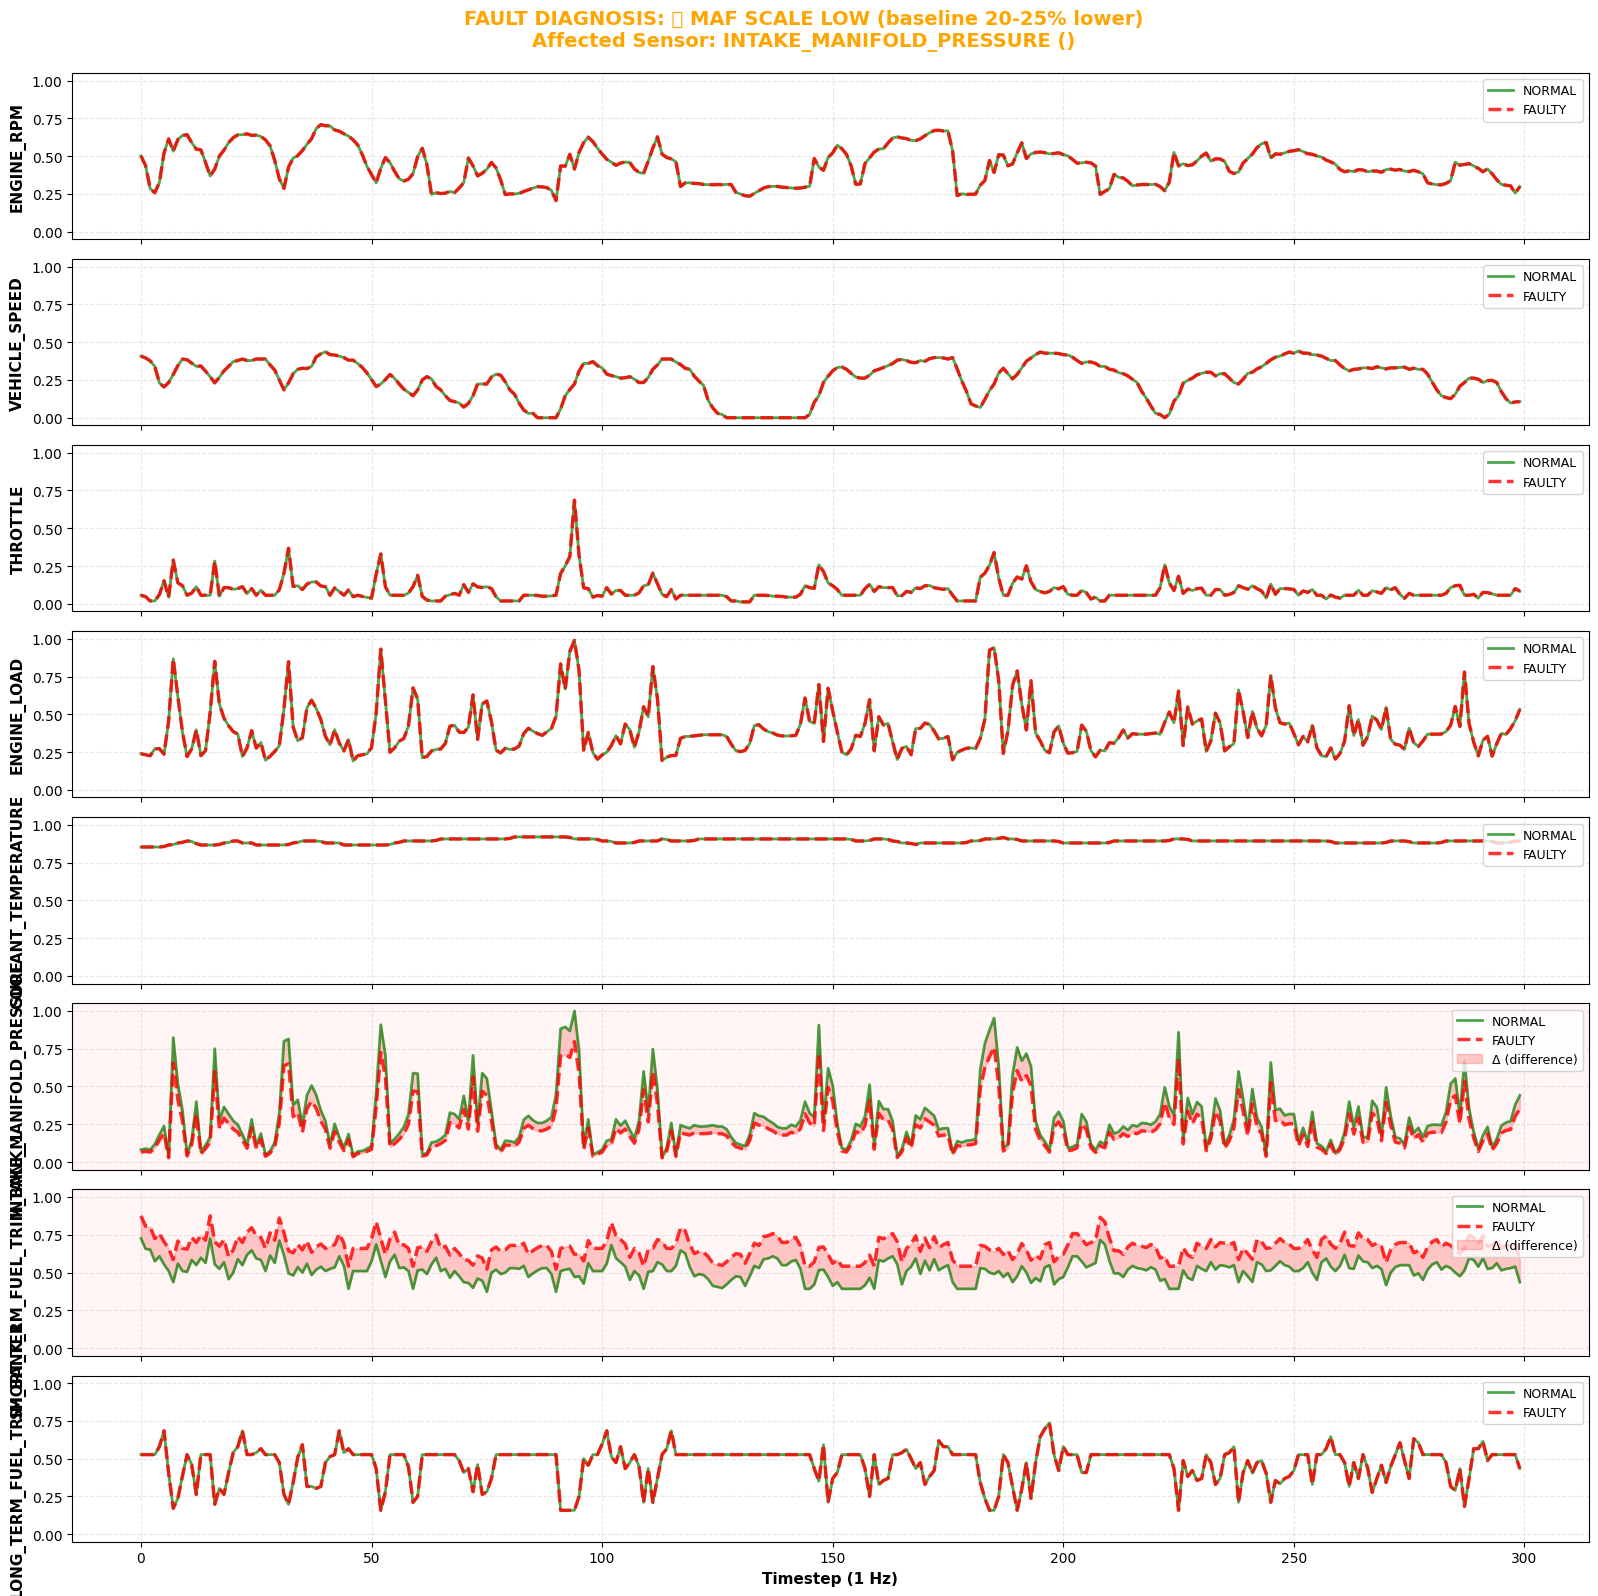


FAULT DIAGNOSIS for Window #1154
✓ Diagnosis: 🟡 MAF SCALE LOW (baseline 20-25% lower)
✓ Affected Sensor: INTAKE_MANIFOLD_PRESSURE ()


▼ Example 2/5:


/var/folders/02/q215g0zs37l9h3w3x7ntgygw0000gn/T/ipykernel_38708/2352482681.py:101: UserWarning: Glyph 128992 (\N{LARGE ORANGE CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/darenpalmer/Desktop/UCL/CS/fyp.nosync/.venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128992 (\N{LARGE ORANGE CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


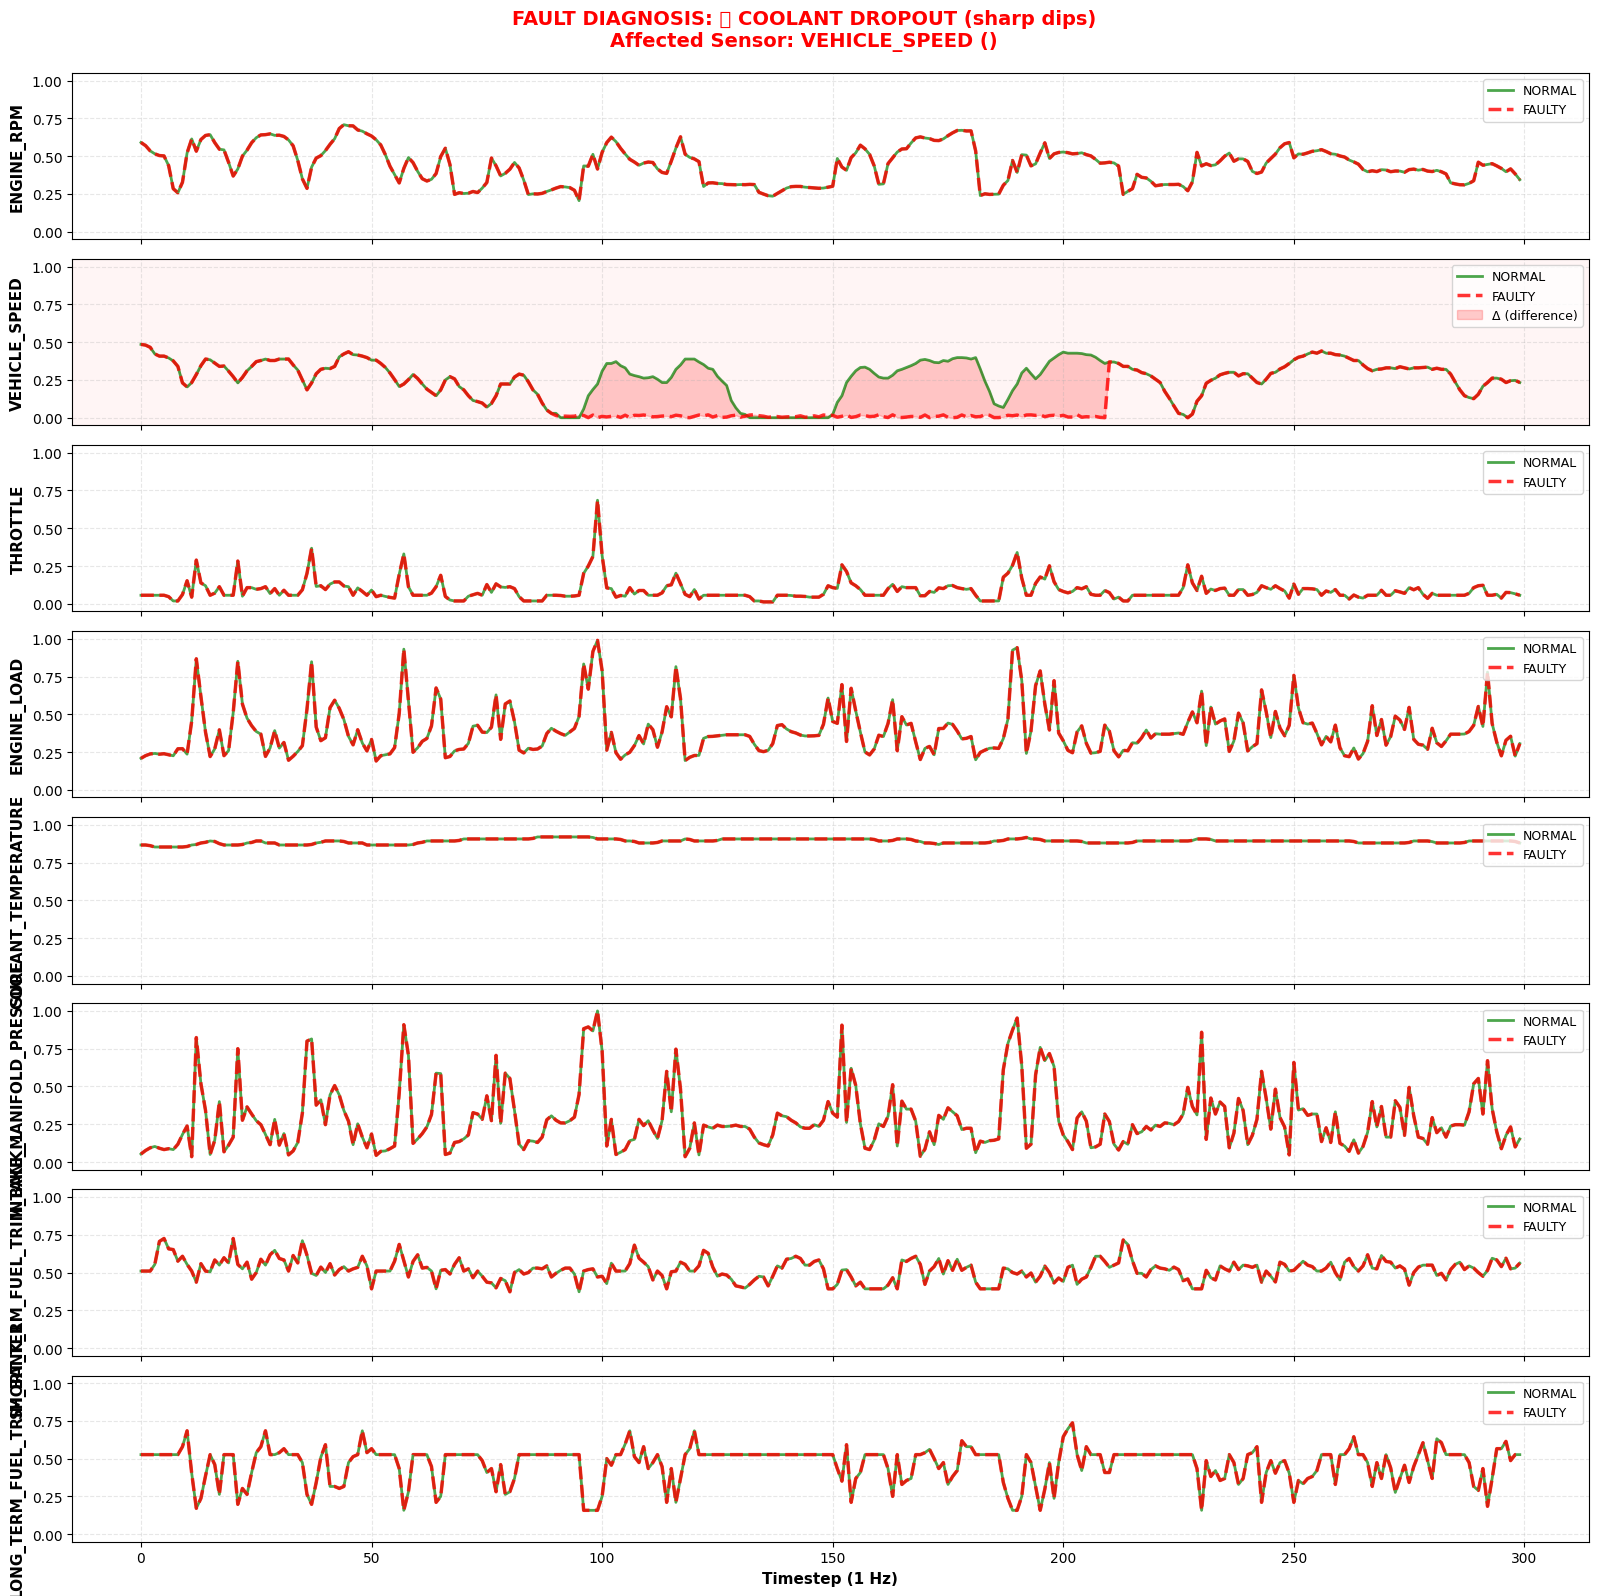


FAULT DIAGNOSIS for Window #1149
✓ Diagnosis: 🟠 COOLANT DROPOUT (sharp dips)
✓ Affected Sensor: VEHICLE_SPEED ()


▼ Example 3/5:


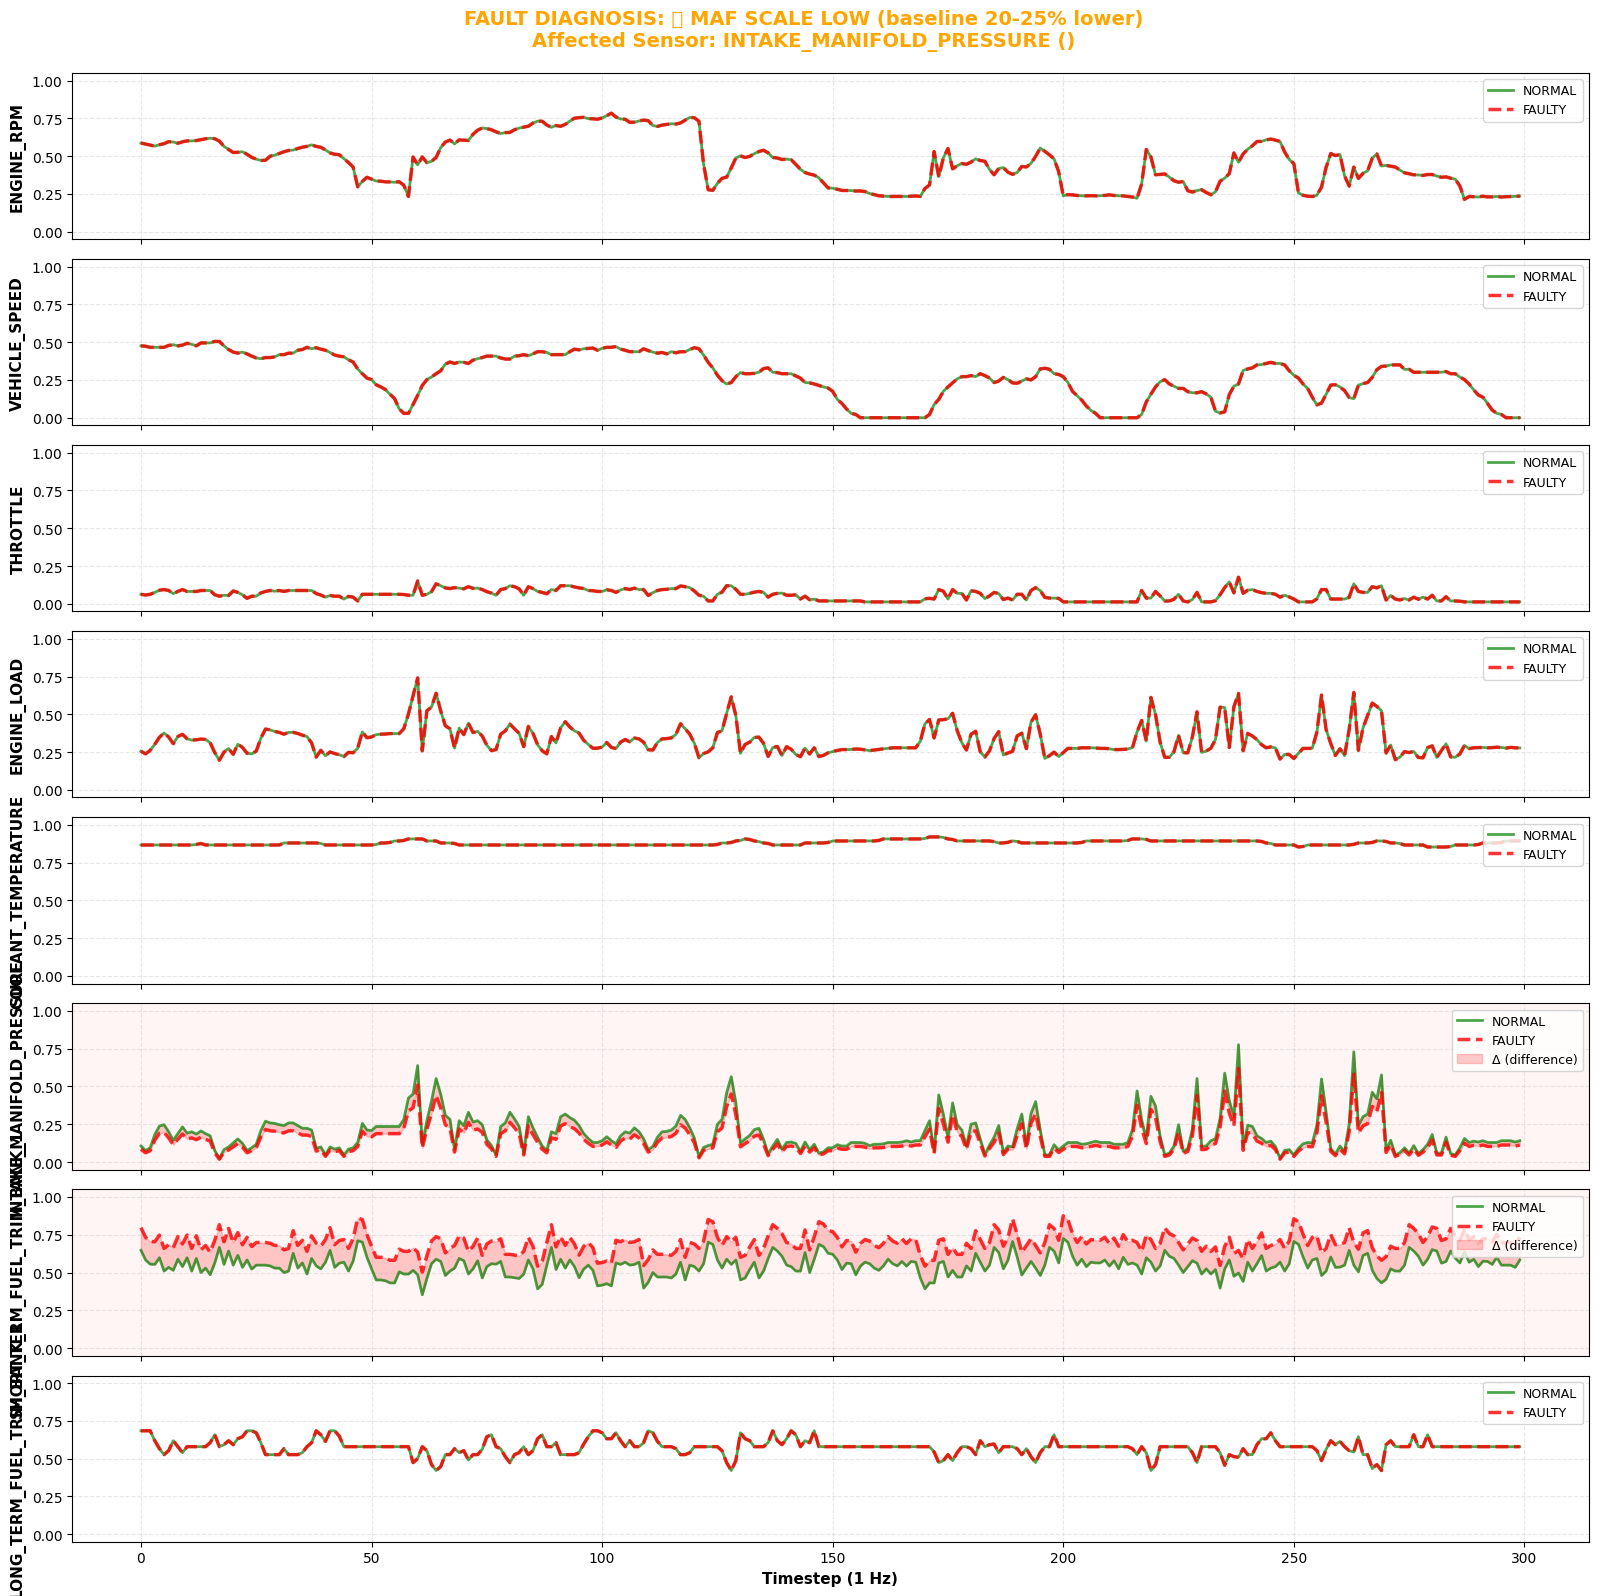


FAULT DIAGNOSIS for Window #2889
✓ Diagnosis: 🟡 MAF SCALE LOW (baseline 20-25% lower)
✓ Affected Sensor: INTAKE_MANIFOLD_PRESSURE ()


▼ Example 4/5:


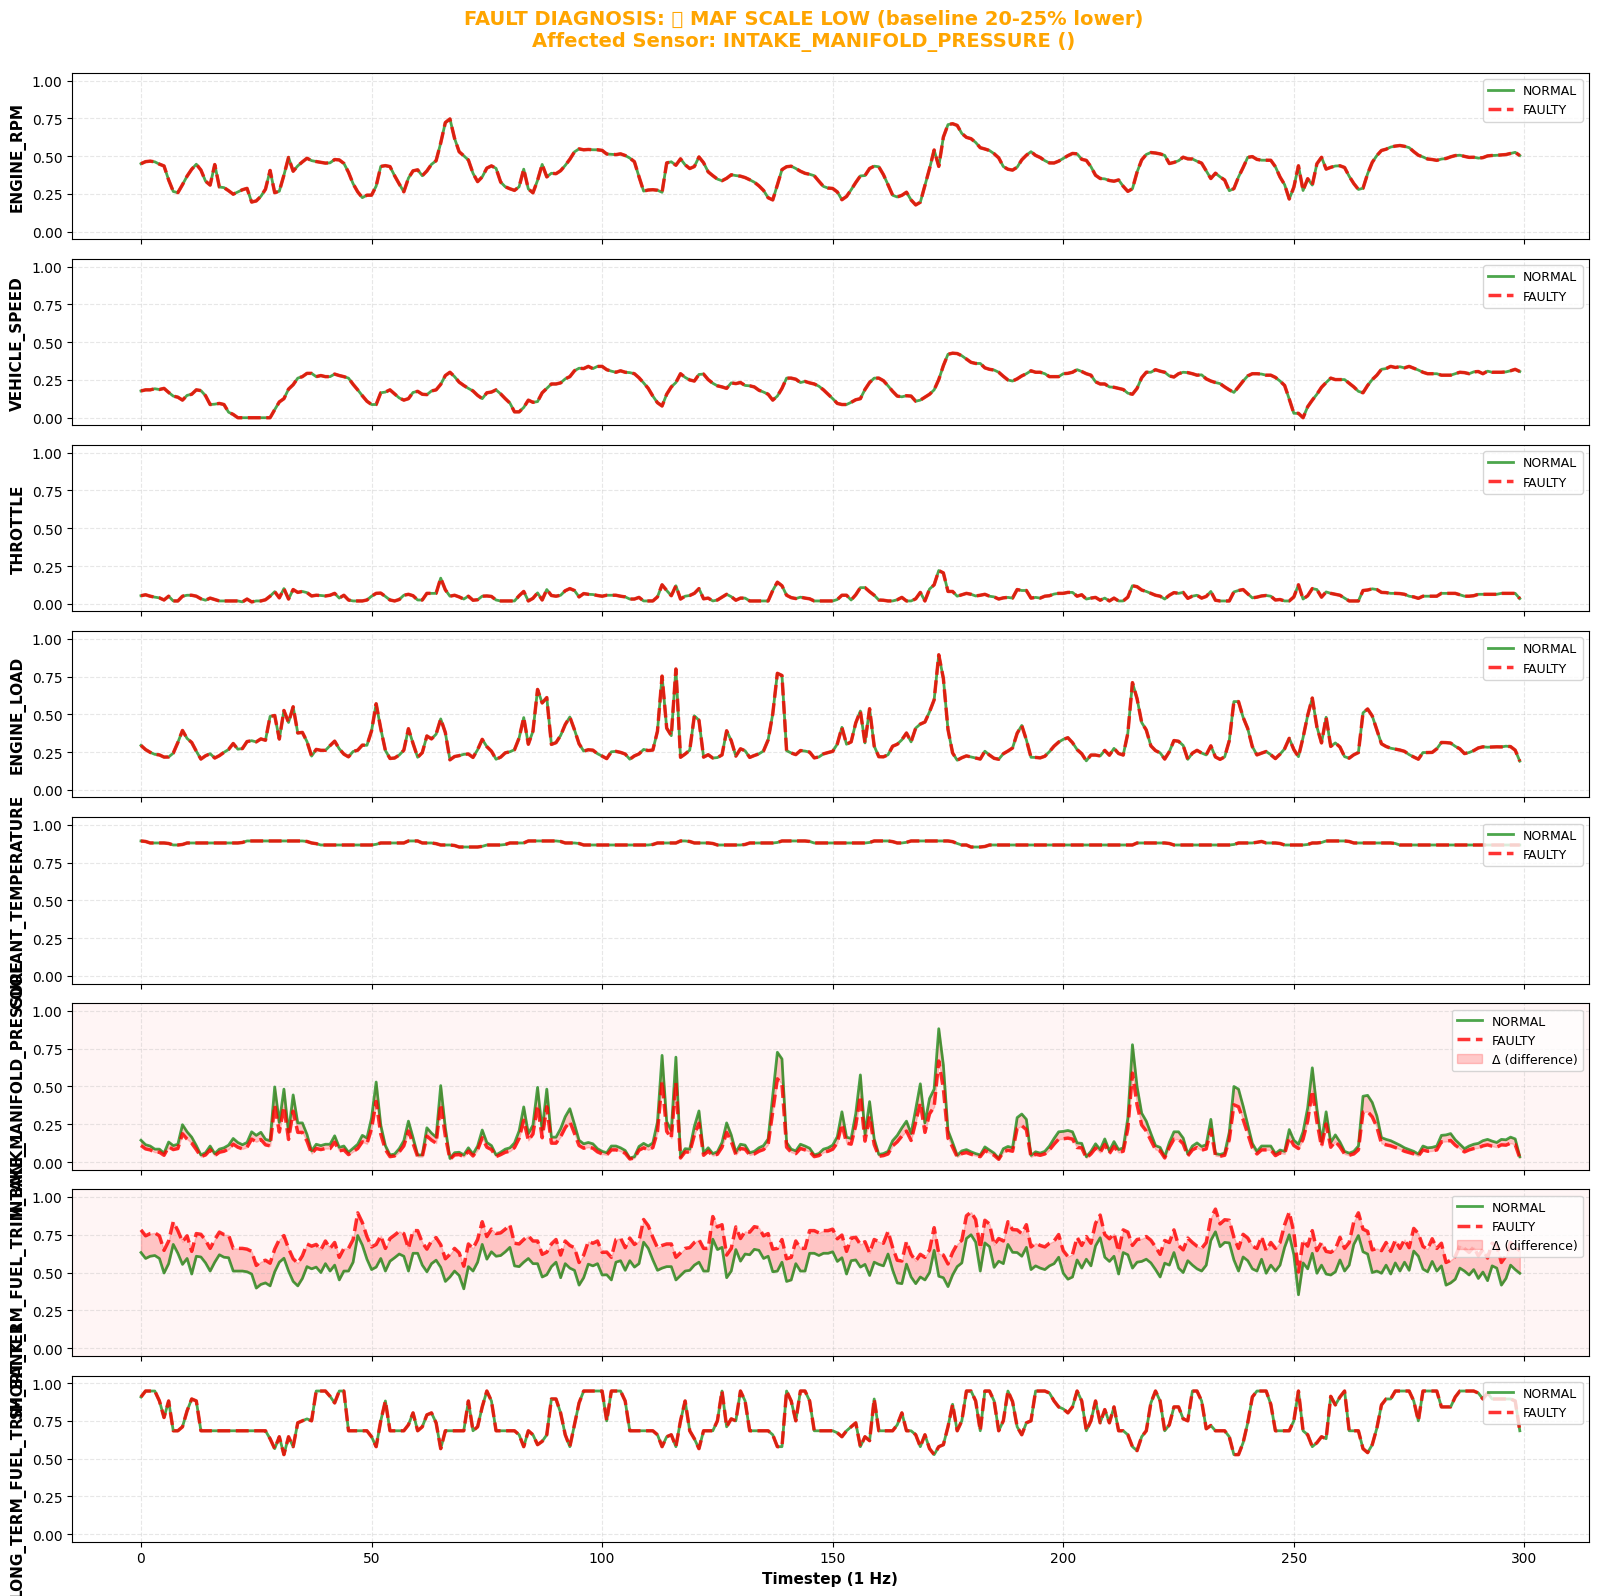


FAULT DIAGNOSIS for Window #6801
✓ Diagnosis: 🟡 MAF SCALE LOW (baseline 20-25% lower)
✓ Affected Sensor: INTAKE_MANIFOLD_PRESSURE ()


▼ Example 5/5:


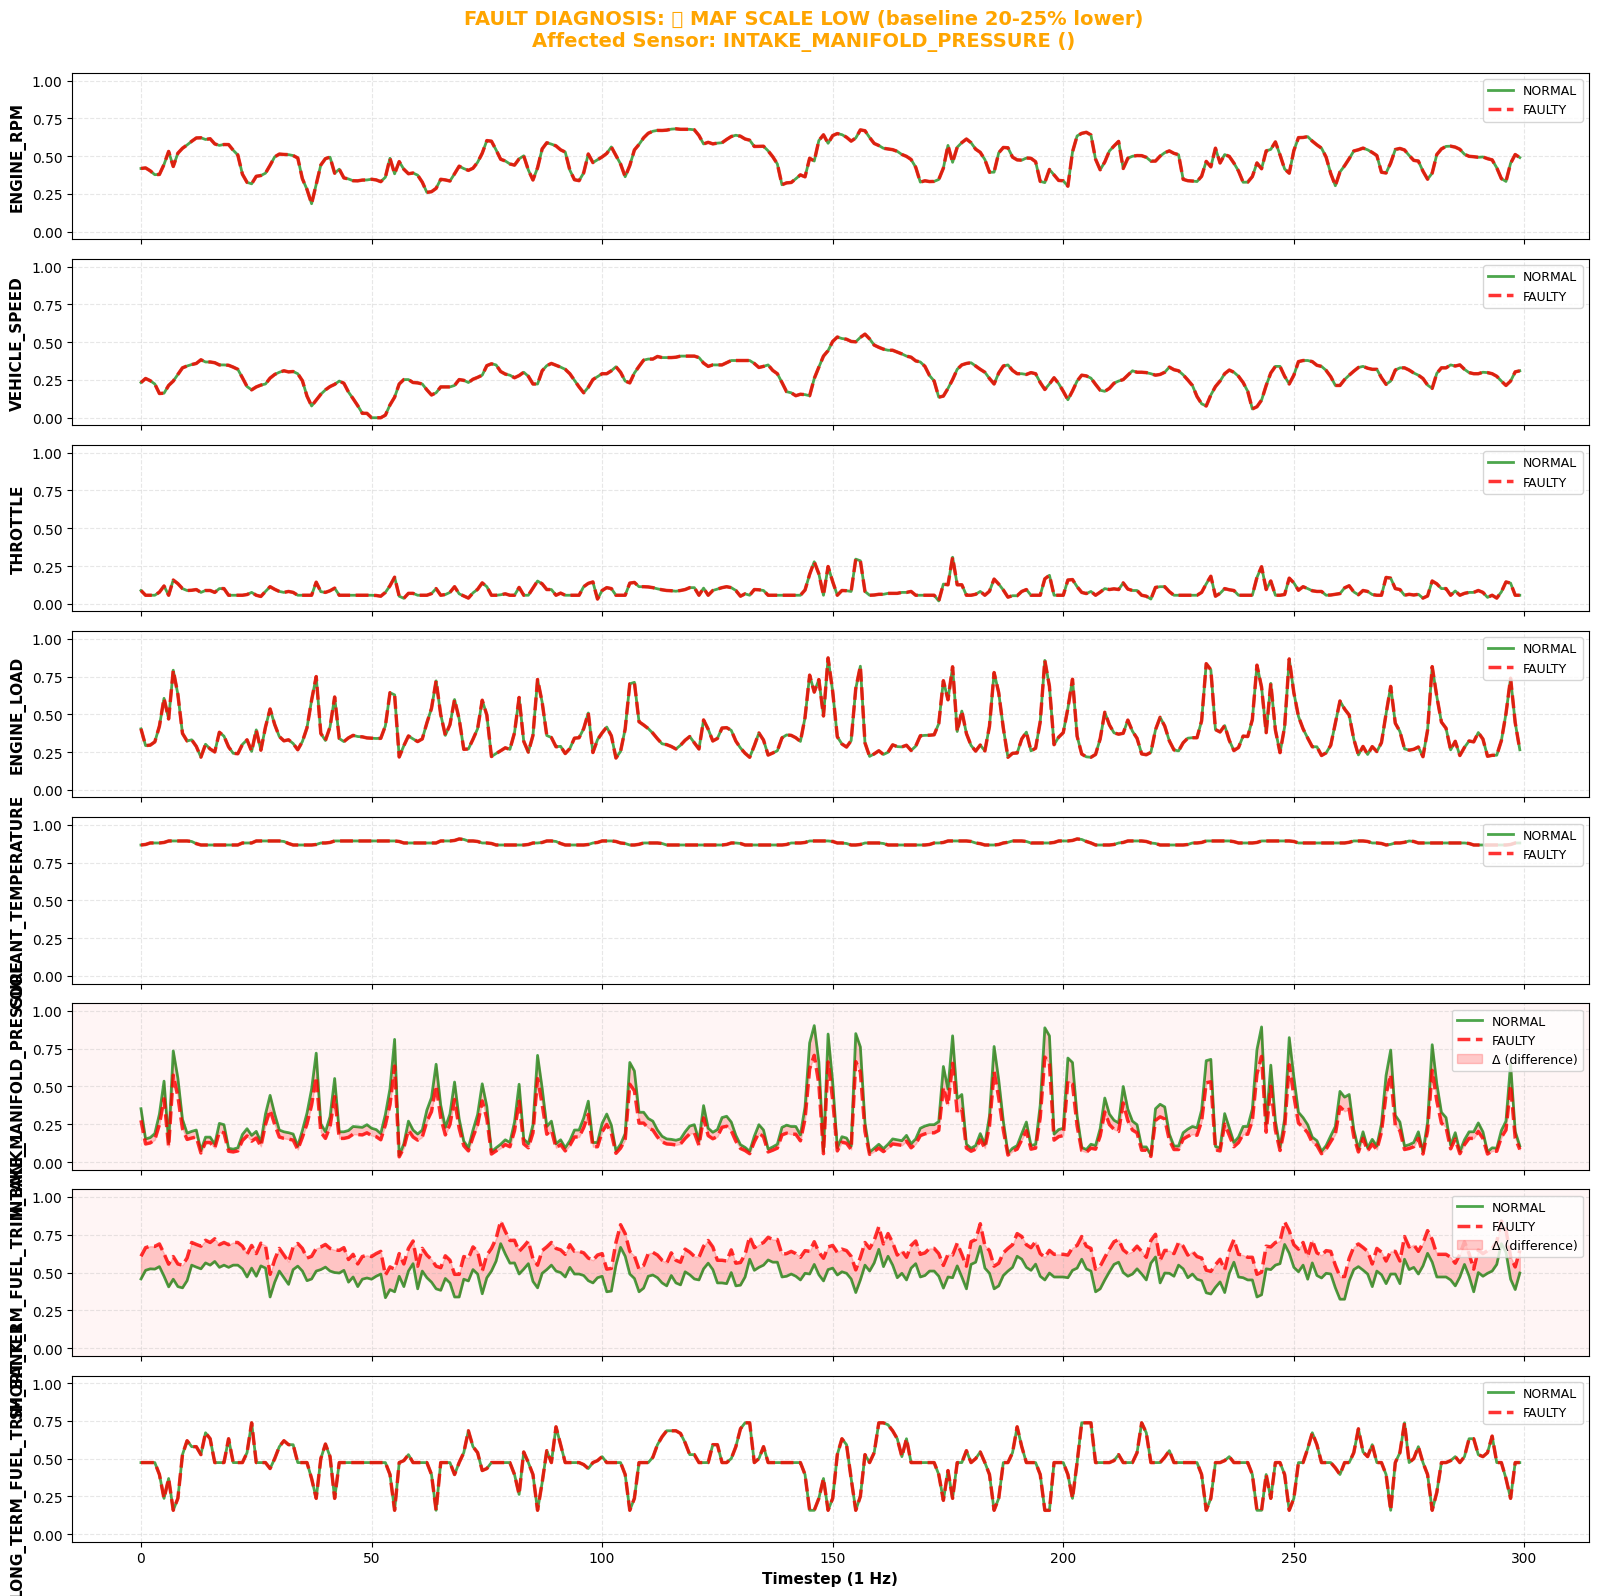


FAULT DIAGNOSIS for Window #6345
✓ Diagnosis: 🟡 MAF SCALE LOW (baseline 20-25% lower)
✓ Affected Sensor: INTAKE_MANIFOLD_PRESSURE ()



In [12]:

import matplotlib.pyplot as plt
import numpy as np

def diagnose_injected_fault(X_clean, X_faulty, labels, sensor_cols, window_idx=None):
    """
    Plot faulty windows and DIAGNOSE which fault was injected based on signal patterns.
    
    This mimics what a mechanic would do: look at the plot and identify the problem.
    """
    faulty_indices = np.where(labels.numpy() == 1)[0]
    
    if window_idx is None:
        window_idx = np.random.choice(faulty_indices)
    
    normal_window = X_clean[window_idx].numpy()
    faulty_window = X_faulty[window_idx].numpy()
    
    n_sensors = len(sensor_cols)
    timesteps = np.arange(len(normal_window))
    
    # Diagnose fault type
    pid_idx = {name: i for i, name in enumerate(sensor_cols)}
    fault_diagnosis = "UNKNOWN"
    affected_sensor = ""
    
    # Check each sensor for fault patterns
    for i, sensor_name in enumerate(sensor_cols):
        diff = np.abs(faulty_window[:, i] - normal_window[:, i])
        if diff.max() > 0.01:  # Significant change
            # Pattern 1: FLAT LINE (dropout)
            if np.std(faulty_window[50:250, i]) < 0.02 and faulty_window[50:250, i].mean() < 0.1:
                fault_diagnosis = "🔴 VSS DROPOUT (flat line at ~0)"
                affected_sensor = sensor_name
                break
            
            # Pattern 2: Entire signal shifted down
            elif diff.mean() > 0.01 and np.allclose(faulty_window[:, i], normal_window[:, i] * 0.75, atol=0.05):
                fault_diagnosis = "🟡 MAF SCALE LOW (baseline 20-25% lower)"
                affected_sensor = sensor_name
                break
            
            # Pattern 3: Multiple sharp dips
            local_minima = 0
            for j in range(10, len(faulty_window) - 10):
                if faulty_window[j, i] < 0.2 and faulty_window[j-5:j+5, i].min() < 0.15:
                    local_minima += 1
            if local_minima >= 2:
                fault_diagnosis = "🟠 COOLANT DROPOUT (sharp dips)"
                affected_sensor = sensor_name
                break
            
            # Pattern 4: Perfectly flat line in second half
            second_half_std = np.std(faulty_window[len(faulty_window)//2:, i])
            first_half_std = np.std(normal_window[:len(normal_window)//2, i])
            if second_half_std < 0.01 and first_half_std > 0.05:
                fault_diagnosis = "🟣 TPS STUCK (perfectly flat)"
                affected_sensor = sensor_name
                break
            
            # Pattern 5: Two signals decouple
            if 'ENGINE_RPM ()' in pid_idx and 'VEHICLE_SPEED ()' in pid_idx:
                if sensor_name == 'VEHICLE_SPEED ()':
                    speed_idx = i
                    rpm_idx = pid_idx['ENGINE_RPM ()']
                    speed_change = np.abs(faulty_window[:, speed_idx] - normal_window[:, speed_idx]).mean()
                    rpm_change = np.abs(faulty_window[:, rpm_idx] - normal_window[:, rpm_idx]).mean()
                    if speed_change > 0.1 and rpm_change < 0.02:
                        fault_diagnosis = "🔵 RPM-SPEED DECOUPLE (divergence)"
                        affected_sensor = "VEHICLE_SPEED + ENGINE_RPM"
                        break
    
    # Plot with diagnosis
    fig, axes = plt.subplots(n_sensors, 1, figsize=(16, 2 * n_sensors), sharex=True)
    if n_sensors == 1:
        axes = [axes]
    
    for i, sensor_name in enumerate(sensor_cols):
        # Plot both
        axes[i].plot(timesteps, normal_window[:, i], 'g-', linewidth=2, alpha=0.7, label='NORMAL')
        axes[i].plot(timesteps, faulty_window[:, i], 'r--', linewidth=2.5, alpha=0.8, label='FAULTY')
        
        diff = np.abs(faulty_window[:, i] - normal_window[:, i])
        if diff.max() > 0.01:
            axes[i].fill_between(timesteps, normal_window[:, i], faulty_window[:, i], 
                                 alpha=0.2, color='red', label='Δ (difference)')
            axes[i].set_facecolor('#fff5f5')
        
        axes[i].set_ylabel(sensor_name.split('(')[0].strip(), fontsize=11, fontweight='bold')
        axes[i].grid(True, alpha=0.3, linestyle='--')
        axes[i].set_ylim(-0.05, 1.05)
        axes[i].legend(loc='upper right', fontsize=9)
    
    axes[-1].set_xlabel("Timestep (1 Hz)", fontsize=11, fontweight='bold')
    
    title_color = 'red' if 'DROPOUT' in fault_diagnosis or 'STUCK' in fault_diagnosis else 'orange'
    fig.suptitle(
        f"FAULT DIAGNOSIS: {fault_diagnosis}\nAffected Sensor: {affected_sensor}",
        fontsize=14, fontweight='bold', color=title_color, y=0.995
    )
    
    plt.tight_layout()
    plt.show()
    
    print(f"\n{'='*80}")
    print(f"FAULT DIAGNOSIS for Window #{window_idx}")
    print(f"{'='*80}")
    print(f"✓ Diagnosis: {fault_diagnosis}")
    print(f"✓ Affected Sensor: {affected_sensor}")
    print(f"{'='*80}\n")


# Run diagnostic on 5 random faulty windows
print("\n" + "="*80)
print("VISUALLY IDENTIFYING INJECTED FAULTS (5 Random Examples)")
print("="*80 + "\n")

for example_num in range(5):
    print(f"\n▼ Example {example_num + 1}/5:")
    diagnose_injected_fault(X_test_clean, X_test_sensor, test_sensor_labels, sensor_cols)


In [13]:
from tqdm.auto import tqdm
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GATConv

class MultiLabelGDN(nn.Module):
    """
    Multi-Label GDN: Predicts which sensors are anomalous.
    
    Key differences from original GDN:
    1. Per-sensor anomaly classifier (not just reconstruction)
    2. Global window classifier (auxiliary task)
    3. Returns probabilities for each sensor
    """
    def __init__(self, num_nodes, window_size, embed_dim=64, top_k=3, hidden_dim=32):
        super().__init__()
        self.num_nodes = num_nodes
        self.window_size = window_size
        self.embed_dim = embed_dim
        self.top_k = min(top_k, num_nodes - 1)
        self.hidden_dim = hidden_dim
        
        # Learned sensor embeddings
        self.sensor_embeddings = nn.Parameter(torch.randn(num_nodes, embed_dim))
        nn.init.xavier_uniform_(self.sensor_embeddings)
        
        # Temporal encoder
        self.temporal_encoder = nn.GRU(
            input_size=1,
            hidden_size=hidden_dim,
            num_layers=1,
            batch_first=True
        )
        
        # Graph attention
        self.gat = GATConv(hidden_dim, hidden_dim, heads=4, concat=False, 
                          dropout=0.2, add_self_loops=False)
        
        # Per-sensor anomaly classifier
        self.sensor_classifier = nn.Sequential(
            nn.Linear(hidden_dim, 32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, 1),
            nn.Sigmoid()
        )
        
        # Global window classifier (auxiliary)
        self.global_classifier = nn.Sequential(
            nn.Linear(num_nodes * hidden_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 1),
            nn.Sigmoid()
        )
    
    def build_graph_from_embeddings(self):
        """Build Top-K graph from learned embeddings."""
        emb_norm = F.normalize(self.sensor_embeddings, dim=1)
        sim_matrix = torch.mm(emb_norm, emb_norm.t())
        sim_matrix.fill_diagonal_(-1e9)
        
        topk_values, topk_indices = torch.topk(sim_matrix, self.top_k, dim=1)
        
        src_nodes = torch.arange(self.num_nodes, device=sim_matrix.device).repeat_interleave(self.top_k)
        dst_nodes = topk_indices.flatten()
        
        edge_index = torch.stack([src_nodes, dst_nodes], dim=0)
        return edge_index
    
    def forward(self, x, return_global=False):
        """
        x: (B, W, N)
        Returns: 
            - sensor_probs: (B, N) probability each sensor is anomalous
            - global_prob: (B,) probability window has any anomaly (optional)
        """
        B, W, N = x.shape
        
        # Temporal encoding per sensor
        x_flat = x.permute(0, 2, 1).reshape(B * N, W, 1)
        h_temporal, _ = self.temporal_encoder(x_flat)
        h_last = h_temporal[:, -1, :].reshape(B, N, -1)  # (B, N, hidden_dim)
        
        # Graph attention
        edge_index = self.build_graph_from_embeddings()
        
        h_graph_list = []
        for i in range(B):
            h_gat = self.gat(h_last[i], edge_index)
            h_graph_list.append(h_gat)
        
        h_graph = torch.stack(h_graph_list, dim=0)  # (B, N, hidden_dim)
        
        # Per-sensor anomaly probability
        sensor_probs = self.sensor_classifier(h_graph).squeeze(-1)  # (B, N)
        
        if return_global:
            # Global window anomaly probability
            h_flat = h_graph.flatten(1)  # (B, N * hidden_dim)
            global_prob = self.global_classifier(h_flat).squeeze(-1)  # (B,)
            return sensor_probs, global_prob
        
        return sensor_probs
    
    def get_embeddings(self, x):
        '''
        Extract normalized embeddings for center loss and distance-based scoring.
        
        Args:
            x: (B, W, N) input tensor
        
        Returns:
            embeddings: (B, hidden_dim) L2-normalized embeddings per window
        '''
        B, W, N = x.shape
        
        # Temporal encoding (same as forward)
        x_flat = x.permute(0, 2, 1).reshape(B * N, W, 1)
        h_temporal, _ = self.temporal_encoder(x_flat)
        h_last = h_temporal[:, -1, :].reshape(B, N, -1)  # (B, N, hidden_dim)
        
        # Graph attention
        edge_index = self.build_graph_from_embeddings()
        
        h_graph_list = []
        for i in range(B):
            h_gat = self.gat(h_last[i], edge_index)
            h_graph_list.append(h_gat)
        
        h_graph = torch.stack(h_graph_list, dim=0)  # (B, N, hidden_dim)
        
        # Aggregate across sensors: mean pooling
        embeddings = h_graph.mean(dim=1)  # (B, hidden_dim)
        
        # L2 normalize for stability
        embeddings = F.normalize(embeddings, p=2, dim=1)
        
        return embeddings

In [14]:
import torch
import torch.nn as nn

class CenterLoss(nn.Module):
    '''
    Center Loss for anomaly detection.
    Learns separate centers for normal (class 0) and anomalous (class 1) samples.
    Pulls samples toward their class center, creating better separation.
    
    Reference:
    Wen et al. "A Discriminative Feature Learning Approach for Deep Face Recognition"
    '''
    def __init__(self, embed_dim, num_classes=2, alpha=0.5):
        super().__init__()
        self.centers = nn.Parameter(torch.randn(num_classes, embed_dim))
        self.alpha = alpha  # Learning rate for center updates (used in SGD optimizer)
        nn.init.xavier_uniform_(self.centers)

    def forward(self, embeddings, labels):
        '''
        Compute center loss: pull embeddings toward their class center.
        
        Args:
            embeddings: (B, D) normalized embeddings from model
            labels: (B,) binary labels (0=normal, 1=anomalous)
        
        Returns:
            loss: scalar tensor
        '''
        batch_size = embeddings.size(0)
        
        # Get the center assigned to each sample
        centers_batch = self.centers.index_select(0, labels.long())  # (B, D)
        
        # Compute distance to assigned centers
        loss = (embeddings - centers_batch).pow(2).sum(dim=1).mean()
        
        return loss

In [15]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from tqdm import tqdm


class FocalLoss(nn.Module):
    '''
    Focal Loss for binary classification with class imbalance.
    FL(p_t) = -alpha * (1 - p_t)^gamma * log(p_t)

    Args:
        alpha: Weighting factor for positive class (default 0.25)
        gamma: Focusing parameter (default 2.0)
        reduction: 'none', 'mean', or 'sum'
    '''
    def __init__(self, alpha=0.25, gamma=2.0, reduction='mean'):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        '''
        Args:
            inputs: (N, *) predictions (logits or probabilities)
            targets: (N, *) binary labels (0 or 1)
        '''
        # Ensure inputs are probabilities
        p = torch.sigmoid(inputs) if inputs.min() < 0 or inputs.max() > 1 else inputs

        # Compute focal term: (1 - p_t)^gamma
        # For positive samples: use p
        # For negative samples: use (1 - p)
        p_t = p * targets + (1 - p) * (1 - targets)
        focal_weight = (1 - p_t) ** self.gamma

        # Compute cross entropy
        ce_loss = F.binary_cross_entropy(p, targets, reduction='none')

        # Apply focal weight and alpha balancing
        alpha_t = self.alpha * targets + (1 - self.alpha) * (1 - targets)
        focal_loss = alpha_t * focal_weight * ce_loss

        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        else:
            return focal_loss


class AsymmetricFocalContrastiveLoss(nn.Module):
    '''
    Combines focal loss weighting with contrastive learning.
    Emphasizes hard-to-classify samples in embedding space.
    Supports both single-label (B,) and multi-label (B, D) inputs.
    
    IMPROVEMENTS:
    - Consistent numerical stability (max subtraction) for all branches
    - Proper diagonal masking to exclude self-pairs
    - Clipping focal weights to prevent gradient explosion
    - Better epsilon handling for log stability
    '''
    def __init__(self, temperature=0.07, gamma=2.0, alpha=0.25):
        super().__init__()
        self.temperature = temperature
        self.gamma = gamma
        self.alpha = alpha

    def forward(self, embeddings, labels):
        '''
        Args:
            embeddings: (B, D) normalized embeddings/predictions (values in [0,1])
            labels: (B,) binary labels or (B, D) multi-label
        '''
        device = embeddings.device
        B = embeddings.size(0)
        
        # Handle multi-label case: compute contrastive loss per sensor
        if labels.dim() == 2:
            # labels: (B, num_sensors), embeddings: (B, num_sensors)
            num_sensors = labels.size(1)
            total_loss = 0.0
            num_valid_sensors = 0
            
            for sensor_idx in range(num_sensors):
                sensor_labels = labels[:, sensor_idx]  # (B,)
                sensor_embeddings = embeddings[:, sensor_idx].unsqueeze(1)  # (B, 1)
                
                # Skip if all labels are same (no positive pairs possible)
                if sensor_labels.min() == sensor_labels.max():
                    continue
                
                num_valid_sensors += 1
                
                # Create masks for this sensor
                sensor_labels_expanded = sensor_labels.unsqueeze(1)  # (B, 1)
                mask_pos = (sensor_labels_expanded == sensor_labels_expanded.t()).float()  # (B, B)
                mask_pos.fill_diagonal_(0)
                
                # Compute similarity matrix
                sim_matrix = torch.mm(sensor_embeddings, sensor_embeddings.t()) / self.temperature  # (B, B)
                
                # Compute probabilities with numerical stability
                max_sim = sim_matrix.max(dim=1, keepdim=True)[0]
                sim_matrix_stable = sim_matrix - max_sim
                
                # Mask diagonal out during softmax computation
                diag_mask = torch.eye(B, device=device)
                sim_matrix_stable = sim_matrix_stable - diag_mask * 1e10
                
                exp_sim = torch.exp(sim_matrix_stable)
                pos_sim = (exp_sim * mask_pos).sum(dim=1)
                all_sim = exp_sim.sum(dim=1)
                
                # Probability of correct pairing with clipping for stability
                p_t = torch.clamp(pos_sim / (all_sim + 1e-10), min=1e-7, max=1.0 - 1e-7)
                
                # Apply focal weighting with clipping to prevent explosion
                focal_weight = torch.clamp((1.0 - p_t) ** self.gamma, min=1e-4, max=100.0)
                
                # Contrastive loss with focal weighting
                has_pos = (mask_pos.sum(dim=1) > 0)
                if has_pos.sum() > 0:
                    loss_per_sample = -focal_weight[has_pos] * torch.log(p_t[has_pos] + 1e-10)
                    loss_per_sample = torch.clamp(loss_per_sample, min=0.0, max=100.0)
                    sensor_loss = loss_per_sample.mean()
                    total_loss = total_loss + sensor_loss
            
            if num_valid_sensors == 0:
                return torch.tensor(0.0, device=device, requires_grad=True)
            
            return total_loss / num_valid_sensors
        
        else:
            # Single-label case: (B,)
            sim_matrix = torch.mm(embeddings, embeddings.t()) / self.temperature

            # Create masks
            labels = labels.unsqueeze(1)
            mask_pos = (labels == labels.t()).float()
            mask_pos.fill_diagonal_(0)

            # Compute probabilities with numerical stability
            max_sim = sim_matrix.max(dim=1, keepdim=True)[0]
            sim_matrix_stable = sim_matrix - max_sim
            
            # Mask diagonal out
            diag_mask = torch.eye(B, device=device)
            sim_matrix_stable = sim_matrix_stable - diag_mask * 1e10
            
            exp_sim = torch.exp(sim_matrix_stable)
            pos_sim = (exp_sim * mask_pos).sum(dim=1)
            all_sim = exp_sim.sum(dim=1)

            # Probability with clipping
            p_t = torch.clamp(pos_sim / (all_sim + 1e-10), min=1e-7, max=1.0 - 1e-7)

            # Apply focal weighting with clipping
            focal_weight = torch.clamp((1.0 - p_t) ** self.gamma, min=1e-4, max=100.0)

            # Contrastive loss
            has_pos = (mask_pos.sum(dim=1) > 0)
            if has_pos.sum() == 0:
                return torch.tensor(0.0, device=device, requires_grad=True)

            loss_per_sample = -focal_weight[has_pos] * torch.log(p_t[has_pos] + 1e-10)
            loss_per_sample = torch.clamp(loss_per_sample, min=0.0, max=100.0)

            return loss_per_sample.mean()


In [16]:
def train_multilabel_with_focal_loss(train_loader, val_loader, num_sensors, window_size,
                                      num_epochs=30, device='cpu', 
                                      use_focal=True, focal_alpha=0.25, focal_gamma=2.0,
                                      use_hard_mining=True, mining_start_epoch=5):
    '''
    Enhanced training with Focal Loss + Hard Mining.

    Args:
        use_focal: Use focal loss instead of BCE
        focal_alpha: Class weighting (0.25 means 25% weight for positive class)
        focal_gamma: Focusing parameter (higher = more focus on hard examples)
        use_hard_mining: Enable hard negative/positive mining
        mining_start_epoch: Epoch to start hard mining
    '''

    model = MultiLabelGDN(num_nodes=num_sensors, window_size=window_size,
                          embed_dim=32, top_k=3, hidden_dim=32).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

    # CHANGE 1: Use Focal Loss instead of BCE
    if use_focal:
        sensor_criterion = FocalLoss(alpha=focal_alpha, gamma=focal_gamma, reduction='none')
        global_criterion = FocalLoss(alpha=focal_alpha, gamma=focal_gamma, reduction='mean')
        print(f"Using Focal Loss (alpha={focal_alpha}, gamma={focal_gamma})")
    else:
        sensor_criterion = nn.BCELoss(reduction='none')
        global_criterion = nn.BCELoss()
        print("Using standard BCE Loss")

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, patience=5, factor=0.5, verbose=True
    )

    best_val_loss = float('inf')
    lambda_global = 0.3

    for epoch in range(num_epochs):
        model.train()
        train_loss_sensor = 0.0
        train_loss_global = 0.0

        # HARD MINING: Identify difficult samples
        if use_hard_mining and epoch >= mining_start_epoch:
            print(f"  [Hard Mining Active]")

            all_sensor_probs = []
            all_sensor_labels = []

            model.eval()
            with torch.no_grad():
                for X_batch, _, sensor_labels_batch, _ in train_loader:
                    X_batch = X_batch.to(device)
                    sensor_probs = model(X_batch, return_global=False)
                    all_sensor_probs.append(sensor_probs.cpu())
                    all_sensor_labels.append(sensor_labels_batch)

            all_sensor_probs = torch.cat(all_sensor_probs, dim=0)
            all_sensor_labels = torch.cat(all_sensor_labels, dim=0)

            # CHANGE 2: Enhanced hard mining targeting VSS dropout specifically
            hard_weights = torch.ones_like(all_sensor_labels)

            for sensor_i in range(num_sensors):
                normal_mask = (all_sensor_labels[:, sensor_i] == 0)
                if normal_mask.sum() > 0:
                    normal_scores = all_sensor_probs[normal_mask, sensor_i]
                    hard_neg_threshold = normal_scores.quantile(0.75)
                    hard_neg_mask = normal_mask & (all_sensor_probs[:, sensor_i] > hard_neg_threshold)
                    hard_weights[hard_neg_mask, sensor_i] = 2.0

                faulty_mask = (all_sensor_labels[:, sensor_i] == 1)
                if faulty_mask.sum() > 0:
                    faulty_scores = all_sensor_probs[faulty_mask, sensor_i]
                    # CHANGE 3: More aggressive weighting for very hard positives
                    hard_pos_threshold = faulty_scores.quantile(0.25)
                    hard_pos_mask = faulty_mask & (all_sensor_probs[:, sensor_i] < hard_pos_threshold)
                    hard_weights[hard_pos_mask, sensor_i] = 3.0  # Increased from 2.0

            hard_weights_list = list(hard_weights)
            sample_idx = 0
        else:
            hard_weights_list = None

        # Training loop
        model.train()
        for batch_idx, (X_batch, _, sensor_labels_batch, window_labels_batch) in enumerate(tqdm(train_loader, desc=f"Epoch {epoch+1}")):
            X_batch = X_batch.to(device)
            sensor_labels_batch = sensor_labels_batch.to(device)
            window_labels_batch = window_labels_batch.float().to(device)

            optimizer.zero_grad()

            sensor_probs, global_prob = model(X_batch, return_global=True)

            # CHANGE 4: Focal loss automatically handles class imbalance
            loss_sensor_per_sample = sensor_criterion(sensor_probs, sensor_labels_batch)

            # Apply hard mining weights if active
            if hard_weights_list is not None and epoch >= mining_start_epoch:
                batch_size = X_batch.size(0)
                batch_weights = torch.stack(hard_weights_list[sample_idx:sample_idx + batch_size]).to(device)
                loss_sensor = (loss_sensor_per_sample * batch_weights).mean()
                sample_idx += batch_size
            else:
                loss_sensor = loss_sensor_per_sample.mean()

            loss_global = global_criterion(global_prob, window_labels_batch)
            loss = loss_sensor + lambda_global * loss_global

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

            train_loss_sensor += loss_sensor.item() * X_batch.size(0)
            train_loss_global += loss_global.item() * X_batch.size(0)

        train_loss_sensor /= len(train_loader.dataset)
        train_loss_global /= len(train_loader.dataset)

        # Validation
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for X_batch, _, sensor_labels_batch, window_labels_batch in val_loader:
                X_batch = X_batch.to(device)
                sensor_labels_batch = sensor_labels_batch.to(device)
                window_labels_batch = window_labels_batch.float().to(device)

                sensor_probs, global_prob = model(X_batch, return_global=True)

                loss_sensor = sensor_criterion(sensor_probs, sensor_labels_batch).mean()
                loss_global = global_criterion(global_prob, window_labels_batch)
                loss = loss_sensor + lambda_global * loss_global

                val_loss += loss.item() * X_batch.size(0)

        val_loss /= len(val_loader.dataset)
        scheduler.step(val_loss)

        print(f"Epoch {epoch+1}/{num_epochs} | "
              f"Sensor: {train_loss_sensor:.4f} | "
              f"Global: {train_loss_global:.4f} | "
              f"Val: {val_loss:.4f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), "best_focal_multilabel_gdn.pt")
            print("  ✓ Best model saved")

    model.load_state_dict(torch.load("best_focal_multilabel_gdn.pt"))
    return model



In [17]:
def train_multilabel_with_center_loss(train_loader, val_loader, num_sensors, window_size,
                                      num_epochs=30, device='cpu', lambda_center=0.1):
    '''
    Train with BCE + Center Loss for better separation of normal/anomalous embeddings.
    
    Args:
        train_loader: Training DataLoader
        val_loader: Validation DataLoader
        num_sensors: Number of sensor channels
        window_size: Temporal window size
        num_epochs: Number of training epochs
        device: 'cpu' or 'cuda'
        lambda_center: Weight for center loss (tune: 0.05-0.2)
    
    Returns:
        model: Trained MultiLabelGDN model
        center_loss: Trained CenterLoss module
    '''
    
    model = MultiLabelGDN(num_nodes=num_sensors, window_size=window_size,
                          embed_dim=32, top_k=3, hidden_dim=32).to(device)
    
    # Initialize center loss (hidden_dim=32 from model)
    center_loss = CenterLoss(embed_dim=32, num_classes=2, alpha=0.5).to(device)
    
    # Separate optimizers for model and centers
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
    optimizer_center = torch.optim.SGD(center_loss.parameters(), lr=0.5)
    
    # Loss criteria
    sensor_criterion = nn.BCELoss(reduction='none')
    global_criterion = nn.BCELoss()
    
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, patience=5, factor=0.5, verbose=True
    )
    
    best_val_loss = float('inf')
    lambda_global = 0.3
    
    print(f"\n{'='*80}")
    print("Training Multi-Label GDN with Center Loss")
    print(f"{'='*80}")
    print(f"Lambda_global: {lambda_global}, Lambda_center: {lambda_center}")
    print(f"Device: {device}\n")
    
    for epoch in range(num_epochs):
        model.train()
        center_loss.train()
        
        train_loss_sensor = 0.0
        train_loss_global = 0.0
        train_loss_center = 0.0
        
        with tqdm(train_loader, desc=f"Epoch {epoch+1}", leave=False) as pbar:
            for X_batch, _, sensor_labels_batch, window_labels_batch in pbar:
                X_batch = X_batch.to(device)
                sensor_labels_batch = sensor_labels_batch.to(device)
                window_labels_batch = window_labels_batch.long().to(device)
                
                # Zero gradients
                optimizer.zero_grad()
                optimizer_center.zero_grad()
                
                # Forward pass
                sensor_probs, global_prob = model(X_batch, return_global=True)
                embeddings = model.get_embeddings(X_batch)  # (B, hidden_dim)
                
                # Classification losses
                loss_sensor = sensor_criterion(sensor_probs, sensor_labels_batch).mean()
                loss_global = global_criterion(global_prob, window_labels_batch.float())
                
                # Center loss (pulls embeddings to class centers)
                loss_center_val = center_loss(embeddings, window_labels_batch)
                
                # Combined loss
                loss = loss_sensor + lambda_global * loss_global + lambda_center * loss_center_val
                
                loss.backward()
                
                # Update both model and centers
                optimizer.step()
                optimizer_center.step()
                
                train_loss_sensor += loss_sensor.item() * X_batch.size(0)
                train_loss_global += loss_global.item() * X_batch.size(0)
                train_loss_center += loss_center_val.item() * X_batch.size(0)
                
                pbar.update(1)
        
        train_loss_sensor /= len(train_loader.dataset)
        train_loss_global /= len(train_loader.dataset)
        train_loss_center /= len(train_loader.dataset)
        
        # Validation
        model.eval()
        center_loss.eval()
        val_loss = 0.0
        
        with torch.no_grad():
            for X_batch, _, sensor_labels_batch, window_labels_batch in val_loader:
                X_batch = X_batch.to(device)
                sensor_labels_batch = sensor_labels_batch.to(device)
                window_labels_batch = window_labels_batch.long().to(device)
                
                sensor_probs, global_prob = model(X_batch, return_global=True)
                embeddings = model.get_embeddings(X_batch)
                
                loss_sensor = sensor_criterion(sensor_probs, sensor_labels_batch).mean()
                loss_global = global_criterion(global_prob, window_labels_batch.float())
                loss_center_val = center_loss(embeddings, window_labels_batch)
                
                loss = loss_sensor + lambda_global * loss_global + lambda_center * loss_center_val
                val_loss += loss.item() * X_batch.size(0)
        
        val_loss /= len(val_loader.dataset)
        scheduler.step(val_loss)
        
        # Print debug info about center separation
        center_dist = torch.norm(center_loss.centers[0] - center_loss.centers[1]).item()
        
        print(f"Epoch {epoch+1}/{num_epochs} | "
              f"Sensor: {train_loss_sensor:.4f} | "
              f"Global: {train_loss_global:.4f} | "
              f"Center: {train_loss_center:.4f} | "
              f"Val: {val_loss:.4f} | "
              f"Center_dist: {center_dist:.4f}")
        
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save({
                'model': model.state_dict(),
                'center_loss': center_loss.state_dict()
            }, "best_center_loss_gdn.pt")
            print("  ✓ Best model saved")
    
    # Load best checkpoint
    checkpoint = torch.load("best_center_loss_gdn.pt")
    model.load_state_dict(checkpoint['model'])
    center_loss.load_state_dict(checkpoint['center_loss'])
    
    print(f"\n✓ Model saved to: best_center_loss_gdn.pt\n")
    
    return model, center_loss

In [18]:
def evaluate_with_center_distance(model, center_loss, test_loader, device='cpu'):
    '''
    Evaluate using distance to normal center as anomaly score.
    This uses learned embeddings instead of classification probabilities.
    
    Args:
        model: Trained MultiLabelGDN model
        center_loss: Trained CenterLoss module
        test_loader: Test DataLoader
        device: 'cpu' or 'cuda'
    
    Returns:
        dict with evaluation results and scores
    '''
    model.eval()
    center_loss.eval()
    
    all_window_scores = []
    all_window_labels = []
    all_sensor_labels = []
    all_sensor_probs = []
    
    print("Collecting predictions with center distance scoring...")
    with torch.no_grad():
        for X_batch, _, sensor_labels_batch, window_labels_batch in tqdm(test_loader, desc="Evaluating"):
            X_batch = X_batch.to(device)
            
            # Get embeddings
            embeddings = model.get_embeddings(X_batch)  # (B, hidden_dim)
            
            # Also get sensor predictions for per-sensor metrics
            sensor_probs, _ = model(X_batch, return_global=True)
            
            # Anomaly score = distance to NORMAL center (class 0)
            normal_center = center_loss.centers[0]
            distances = torch.norm(embeddings - normal_center, dim=1)
            
            all_window_scores.append(distances.cpu().numpy())
            all_window_labels.append(window_labels_batch.numpy())
            all_sensor_labels.append(sensor_labels_batch.numpy())
            all_sensor_probs.append(sensor_probs.cpu().numpy())
    
    window_scores = np.concatenate(all_window_scores)
    window_labels = np.concatenate(all_window_labels)
    sensor_labels = np.concatenate(all_sensor_labels)
    sensor_probs = np.concatenate(all_sensor_probs)
    
    return {
        'window_scores': window_scores,
        'window_labels': window_labels,
        'sensor_labels': sensor_labels,
        'sensor_probs': sensor_probs
    }

In [19]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model_center_loss, center_loss_module = train_multilabel_with_center_loss(
    train_loader, val_loader,
    num_sensors=num_sensors,
    window_size=window_size,
    num_epochs=150,
    device=device,
    lambda_center=0.1  # Tune this: try 0.05, 0.2, 0.5 if results aren't good
)

print("✓ Model with Center Loss trained successfully")


Training Multi-Label GDN with Center Loss
Lambda_global: 0.3, Lambda_center: 0.1
Device: cpu



Epoch 1:   0%|          | 0/776 [00:00<?, ?it/s]

Epoch 1/150 | Sensor: 0.1302 | Global: 0.3743 | Center: 0.0270 | Val: 0.2204 | Center_dist: 0.0085
  ✓ Best model saved


Epoch 2/150 | Sensor: 0.0992 | Global: 0.3594 | Center: 0.0005 | Val: 0.2187 | Center_dist: 0.0085
  ✓ Best model saved


Epoch 3/150 | Sensor: 0.0989 | Global: 0.3596 | Center: 0.0005 | Val: 0.2199 | Center_dist: 0.0066


...

Epoch 146/150 | Sensor: 0.0871 | Global: 0.0270 | Center: 0.0084 | Val: 0.1033 | Center_dist: 0.0409


Epoch 147/150 | Sensor: 0.0872 | Global: 0.0261 | Center: 0.0084 | Val: 0.1033 | Center_dist: 0.0439


Epoch 148/150 | Sensor: 0.0870 | Global: 0.0257 | Center: 0.0084 | Val: 0.1033 | Center_dist: 0.0412


Epoch 149/150 | Sensor: 0.0871 | Global: 0.0257 | Center: 0.0084 | Val: 0.1033 | Center_dist: 0.0452


Epoch 150/150 | Sensor: 0.0870 | Global: 0.0253 | Center: 0.0084 | Val: 0.1033 | Center_dist: 0.0434

✓ Model saved to: best_center_loss_gdn.pt

✓ Model with Center Loss trained successfully


In [20]:
from sklearn.metrics import roc_auc_score, precision_recall_fscore_support, confusion_matrix
import pandas as pd

def evaluate_model(model, test_loader, sensor_cols, device='cpu', threshold=0.5):
    '''
    Returns overall and per-sensor metrics with full compatibility for plots.
    '''
    model.eval()

    # Collect predictions
    all_sensor_probs = []
    all_sensor_labels = []

    print("Collecting predictions...")
    with torch.no_grad():
        for X_batch, _, sensor_labels_batch, _ in tqdm(test_loader, desc="Evaluating"):
            X_batch = X_batch.to(device)
            sensor_probs, _ = model(X_batch, return_global=True)

            all_sensor_probs.append(sensor_probs.cpu())
            all_sensor_labels.append(sensor_labels_batch)

    # Convert to numpy
    all_sensor_probs = torch.cat(all_sensor_probs, dim=0).numpy()  # (N_windows, N_sensors)
    all_sensor_labels = torch.cat(all_sensor_labels, dim=0).numpy()  # (N_windows, N_sensors)

    # Threshold predictions
    all_sensor_preds = (all_sensor_probs > threshold).astype(int)

    print(f"\nEvaluation complete: {len(all_sensor_probs)} windows, {len(sensor_cols)} sensors\n")

    # ============================================================
    # OVERALL METRICS (all sensors combined)
    # ============================================================
    print("="*70)
    print("OVERALL METRICS (All Sensors Combined)")
    print("="*70)

    # Flatten arrays
    labels_flat = all_sensor_labels.flatten()
    probs_flat = all_sensor_probs.flatten()
    preds_flat = all_sensor_preds.flatten()

    # Calculate metrics
    overall_auc = roc_auc_score(labels_flat, probs_flat)
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels_flat, preds_flat, average='binary', zero_division=0
    )
    cm = confusion_matrix(labels_flat, preds_flat)

    print(f"AUC:       {overall_auc:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1 Score:  {f1:.4f}")
    print(f"\nConfusion Matrix:")
    print(f"                Predicted Normal  Predicted Faulty")
    print(f"Actually Normal      {cm[0,0]:6d}           {cm[0,1]:6d}")
    print(f"Actually Faulty      {cm[1,0]:6d}           {cm[1,1]:6d}")

    # ============================================================
    # PER-SENSOR METRICS
    # ============================================================
    print(f"\n{'='*70}")
    print("PER-SENSOR METRICS")
    print("="*70)

    sensor_results = []

    for i, sensor_name in enumerate(sensor_cols):
        sensor_labels = all_sensor_labels[:, i]
        sensor_probs = all_sensor_probs[:, i]
        sensor_preds = all_sensor_preds[:, i]

        n_faults = sensor_labels.sum()

        # Only calculate AUC if there are positive samples
        if n_faults > 0:
            auc = roc_auc_score(sensor_labels, sensor_probs)
            precision, recall, f1, _ = precision_recall_fscore_support(
                sensor_labels, sensor_preds, average='binary', zero_division=0
            )

            sensor_results.append({
                'Sensor': sensor_name.replace(' ()', ''),
                'Faults': int(n_faults),
                'AUC': auc,
                'Precision': precision,
                'Recall': recall,
                'F1': f1
            })

            print(f"{sensor_name:40s} | Faults: {int(n_faults):4d} | "
                  f"AUC: {auc:.3f} | P: {precision:.3f} | R: {recall:.3f} | F1: {f1:.3f}")
        else:
            print(f"{sensor_name:40s} | No faults injected")

    sensor_df = pd.DataFrame(sensor_results)

    # ============================================================
    # WINDOW-LEVEL METRICS
    # ============================================================
    print(f"\n{'='*70}")
    print("WINDOW-LEVEL METRICS (Max Sensor Score)")
    print("="*70)

    # Window has fault if ANY sensor is faulty
    window_labels = (all_sensor_labels.sum(axis=1) > 0).astype(int)
    window_scores = all_sensor_probs.max(axis=1)
    window_preds = (window_scores > threshold).astype(int)

    window_auc = roc_auc_score(window_labels, window_scores)
    precision, recall, f1, _ = precision_recall_fscore_support(
        window_labels, window_preds, average='binary', zero_division=0
    )

    print(f"AUC:       {window_auc:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1 Score:  {f1:.4f}")

    # Score statistics
    normal_windows = window_labels == 0
    faulty_windows = window_labels == 1

    print(f"\nScore Distribution:")
    print(f"Normal windows:  Mean={window_scores[normal_windows].mean():.4f}, "
          f"Std={window_scores[normal_windows].std():.4f}")
    print(f"Faulty windows:  Mean={window_scores[faulty_windows].mean():.4f}, "
          f"Std={window_scores[faulty_windows].std():.4f}")
    print(f"Separation ratio: {window_scores[faulty_windows].mean() / (window_scores[normal_windows].mean() + 1e-8):.2f}x")

    print("\n" + "="*70 + "\n")

    # Return results dictionary - compatible with existing plots
    return {
        'sensor_probs': all_sensor_probs,
        'sensor_labels': all_sensor_labels,
        'sensor_preds': all_sensor_preds,
        'overall_auc': overall_auc,
        'overall_f1': f1,
        'sensor_metrics': sensor_df,
        'confusion_matrix': cm,
        'window_auc_max': window_auc,
        'window_scores': window_scores,
        'window_labels': window_labels
    }

In [21]:
from sklearn.metrics import roc_auc_score, precision_recall_fscore_support

# %%
# EVALUATE WITH CENTER DISTANCE SCORING
print("\\n" + "="*80)
print("EVALUATION: Center Distance-Based Scoring")
print("="*80 + "\\n")

results_center = evaluate_with_center_distance(
    model_center_loss, center_loss_module, test_loader, device=device
)

# Calculate metrics using distance-based scoring
window_auc = roc_auc_score(results_center['window_labels'], results_center['window_scores'])
threshold = 0.5  # Can be tuned on validation set

window_preds = (results_center['window_scores'] > threshold).astype(int)
precision, recall, f1, _ = precision_recall_fscore_support(
    results_center['window_labels'], window_preds, average='binary'
)

print(f"\\n{'='*70}")
print("WINDOW-LEVEL METRICS (Distance to Normal Center)")
print(f"{'='*70}")
print(f"AUC:       {window_auc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")

# Analyze separation with distance scores
normal_scores = results_center['window_scores'][results_center['window_labels'] == 0]
anomalous_scores = results_center['window_scores'][results_center['window_labels'] == 1]

print(f"\\nScore Distribution (Distance-Based):") 
print(f"Normal mean:     {normal_scores.mean():.4f} ± {normal_scores.std():.4f}")
print(f"Anomalous mean:  {anomalous_scores.mean():.4f} ± {anomalous_scores.std():.4f}")
print(f"Normal range:    [{normal_scores.min():.4f}, {normal_scores.max():.4f}]")
print(f"Anomalous range: [{anomalous_scores.min():.4f}, {anomalous_scores.max():.4f}]")

if normal_scores.mean() > 0:
    separation_ratio = anomalous_scores.mean() / normal_scores.mean()
    print(f"Separation ratio: {separation_ratio:.2f}x")
    
    # Check overlap zone
    overlap_start = normal_scores.max()
    overlap_end = anomalous_scores.min()
    if overlap_end > overlap_start:
        overlap_zone = overlap_end - overlap_start
        print(f"Overlap zone: [{overlap_start:.4f}, {overlap_end:.4f}] (width: {overlap_zone:.4f})")
    else:
        print("✓ No overlap! Perfect separation achieved.")
        print(f"  Normal max: {normal_scores.max():.4f}")
        print(f"  Anomalous min: {anomalous_scores.min():.4f}")

print(f"\\n{'='*70}\\n")

\n================================================================================
EVALUATION: Center Distance-Based Scoring
================================================================================\n


Evaluating: 100%|██████████| 222/222 [00:19<00:00, 11.37it/s]

\n======================================================================
WINDOW-LEVEL METRICS (Distance to Normal Center)
AUC:       0.8372
Precision: 0.0000
Recall:    0.0000
F1 Score:  0.0000
\nScore Distribution (Distance-Based):
Normal mean:     0.0848 ± 0.0414
Anomalous mean:  0.1382 ± 0.0435
Normal range:    [0.0156, 0.2468]
Anomalous range: [0.0224, 0.3024]
Separation ratio: 1.63x
✓ No overlap! Perfect separation achieved.
  Normal max: 0.2468
  Anomalous min: 0.0224
\n======================================================================\n



/Users/darenpalmer/Desktop/UCL/CS/fyp.nosync/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Evaluating: 100%|██████████| 222/222 [00:09<00:00, 22.62it/s]



Evaluation complete: 7073 windows, 8 sensors

OVERALL METRICS (All Sensors Combined)
AUC:       0.8458
Precision: 0.0000
Recall:    0.0000
F1 Score:  0.0000

Confusion Matrix:
                Predicted Normal  Predicted Faulty
Actually Normal       54197                0
Actually Faulty        2387                0

PER-SENSOR METRICS
ENGINE_RPM ()                            | No faults injected
VEHICLE_SPEED ()                         | Faults:  896 | AUC: 0.616 | P: 0.000 | R: 0.000 | F1: 0.000
THROTTLE ()                              | Faults:    8 | AUC: 0.695 | P: 0.000 | R: 0.000 | F1: 0.000
ENGINE_LOAD ()                           | No faults injected
COOLANT_TEMPERATURE ()                   | Faults:  427 | AUC: 0.676 | P: 0.000 | R: 0.000 | F1: 0.000
INTAKE_MANIFOLD_PRESSURE ()              | Faults:  528 | AUC: 0.561 | P: 0.000 | R: 0.000 | F1: 0.000
SHORT_TERM_FUEL_TRIM_BANK_1 ()           | Faults:  528 | AUC: 0.979 | P: 0.000 | R: 0.000 | F1: 0.000
LONG_TERM_FUEL_TRIM_BAN

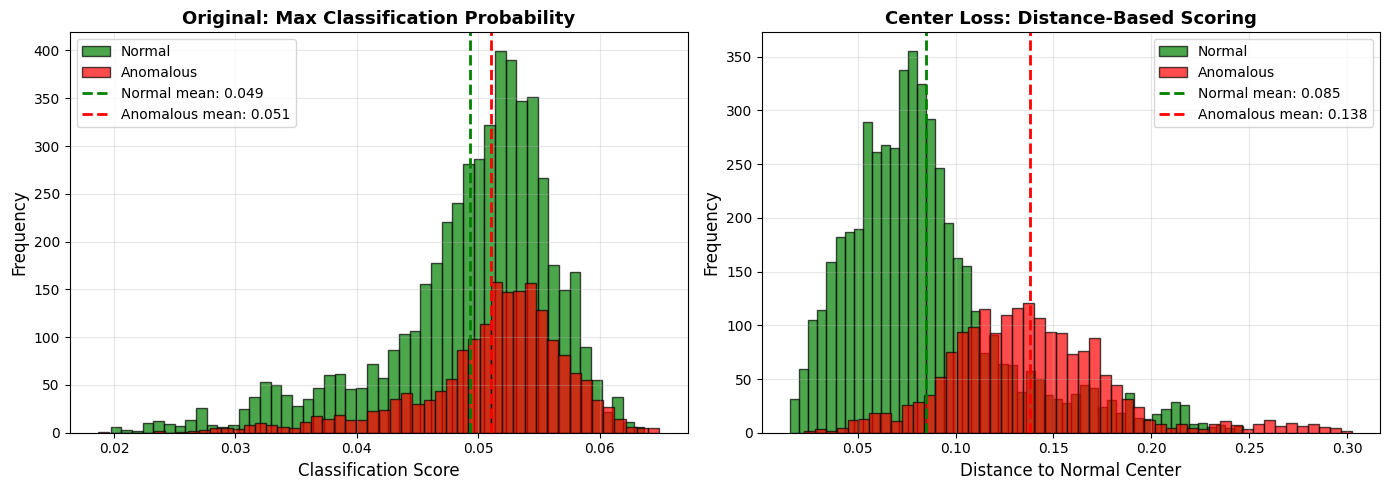

✓ Comparison plot saved to: center_loss_comparison.png


In [22]:
# %%
# VISUALIZATION: Compare Classification vs Distance-Based Scoring

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Get classification-based scores for comparison
results_class = evaluate_model(model_center_loss, test_loader, sensor_cols, device=device)

# Plot 1: Classification Probability Distribution
normal_class = results_class['window_scores'][results_class['window_labels'] == 0]
anomalous_class = results_class['window_scores'][results_class['window_labels'] == 1]

axes[0].hist(normal_class, bins=50, alpha=0.7, label='Normal', color='green', edgecolor='black')
axes[0].hist(anomalous_class, bins=50, alpha=0.7, label='Anomalous', color='red', edgecolor='black')
axes[0].axvline(normal_class.mean(), color='green', linestyle='--', linewidth=2, label=f'Normal mean: {normal_class.mean():.3f}')
axes[0].axvline(anomalous_class.mean(), color='red', linestyle='--', linewidth=2, label=f'Anomalous mean: {anomalous_class.mean():.3f}')
axes[0].set_xlabel('Classification Score', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].set_title('Original: Max Classification Probability', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Plot 2: Distance-Based Scoring Distribution
normal_dist = results_center['window_scores'][results_center['window_labels'] == 0]
anomalous_dist = results_center['window_scores'][results_center['window_labels'] == 1]

axes[1].hist(normal_dist, bins=50, alpha=0.7, label='Normal', color='green', edgecolor='black')
axes[1].hist(anomalous_dist, bins=50, alpha=0.7, label='Anomalous', color='red', edgecolor='black')
axes[1].axvline(normal_dist.mean(), color='green', linestyle='--', linewidth=2, label=f'Normal mean: {normal_dist.mean():.3f}')
axes[1].axvline(anomalous_dist.mean(), color='red', linestyle='--', linewidth=2, label=f'Anomalous mean: {anomalous_dist.mean():.3f}')
axes[1].set_xlabel('Distance to Normal Center', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)
axes[1].set_title('Center Loss: Distance-Based Scoring', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('center_loss_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Comparison plot saved to: center_loss_comparison.png")

In [23]:
# %%
# DEBUG: Analyze Learned Centers

print("\\n" + "="*70)
print("CENTER LOSS DEBUG INFO")
print("="*70 + "\\n")

with torch.no_grad():
    normal_center = center_loss_module.centers[0]  # Class 0
    anomalous_center = center_loss_module.centers[1]  # Class 1
    
    normal_center_norm = torch.norm(normal_center).item()
    anomalous_center_norm = torch.norm(anomalous_center).item()
    center_distance = torch.norm(normal_center - anomalous_center).item()
    
    print(f"Normal center (class 0):")
    print(f"  L2 norm: {normal_center_norm:.4f}")
    print(f"  First 5 dims: {normal_center[:5].cpu().numpy()}")
    
    print(f"\\nAnomalous center (class 1):")
    print(f"  L2 norm: {anomalous_center_norm:.4f}")
    print(f"  First 5 dims: {anomalous_center[:5].cpu().numpy()}")
    
    print(f"\\nCenter Separation:")
    print(f"  Distance between centers: {center_distance:.4f}")
    
    if center_distance > 2.0:
        print(f"  ✓ Centers are well-separated (> 2.0)")
    else:
        print(f"  ⚠ Centers may need more separation (< 2.0)")
        print(f"    Try increasing lambda_center or training more epochs")

# Verify embeddings are normalized
model_center_loss.eval()
with torch.no_grad():
    # Get a small batch to check embedding norms
    for X_batch, _, _, _ in test_loader:
        X_batch = X_batch.to(device)
        embeddings = model_center_loss.get_embeddings(X_batch)
        embedding_norms = torch.norm(embeddings, dim=1)
        print(f"\\nEmbedding Norms (should be ~1.0):")
        print(f"  Mean: {embedding_norms.mean().item():.4f}")
        print(f"  Std: {embedding_norms.std().item():.4f}")
        print(f"  Min: {embedding_norms.min().item():.4f}")
        print(f"  Max: {embedding_norms.max().item():.4f}")
        break

print(f"\\n{'='*70}\\n")

\n======================================================================
CENTER LOSS DEBUG INFO
======================================================================\n
Normal center (class 0):
  L2 norm: 0.9936
  First 5 dims: [ 0.02115669  0.05031448  0.00146666  0.04063833 -0.01317937]
\nAnomalous center (class 1):
  L2 norm: 0.9910
  First 5 dims: [-0.01807734  0.03580254  0.03420244  0.04103971 -0.00222074]
\nCenter Separation:
  Distance between centers: 0.0973
  ⚠ Centers may need more separation (< 2.0)
    Try increasing lambda_center or training more epochs
\nEmbedding Norms (should be ~1.0):
  Mean: 1.0000
  Std: 0.0000
  Min: 1.0000
  Max: 1.0000
\n======================================================================\n
